In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 1. 파일 불러오기 (인코딩은 상황에 맞게 'euc-kr' 또는 'utf-8' 선택)
# 구글 시트에서 저장한 파일이라면 보통 'utf-8'입니다.
df = pd.read_csv('data/real_estate_total.csv', encoding='euc-kr', parse_dates=["계약일"])
df

C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\2541086942.py:9: DtypeWarning: Columns (19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_total.csv', encoding='euc-kr', parse_dates=["계약일"])


,접수연도,자치구코드,자치구명,법정동코드,법정동명,지번구분,지번구분명,본번,부번,건물명,...,물건금액(만원),건물면적(㎡),토지면적(㎡),층,권리구분,취소일,건축년도,건물용도,신고구분,신고한_개업공인중개사_시군구명
0,2018,11500,강서구,10300,화곡동,1.0,대지,1159.0,0.0,"우장산아이파크,이편한세상",...,95000,101.65,NaN,10.0,NaN,NaN,2008.0,아파트,NaN,NaN
1,2018,11410,서대문구,11200,대현동,1.0,대지,144.0,0.0,럭키대현,...,70000,83.38,NaN,10.0,NaN,NaN,1999.0,아파트,NaN,NaN
2,2018,11590,동작구,10700,사당동,1.0,대지,169.0,32.0,현대,...,49500,51.66,NaN,10.0,NaN,NaN,1991.0,아파트,NaN,NaN
3,2018,11350,노원구,10500,상계동,1.0,대지,1380.0,4.0,초산빌라,...,16000,41.37,18.38,1.0,NaN,NaN,1996.0,연립다세대,NaN,NaN
4,2018,11380,은평구,11000,증산동,1.0,대지,189.0,63.0,궁전맨션(189-63),...,43000,54.34,27.17,2.0,NaN,NaN,1992.0,연립다세대,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,2024,11530,구로구,10700,개봉동,1.0,대지,170.0,33.0,금석연립(170-33),...,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래,서울 강남구
833610,2024,11530,구로구,10700,개봉동,1.0,대지,170.0,33.0,금석연립(170-33),...,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래,서울 강남구
833611,2024,11530,구로구,10700,개봉동,1.0,대지,170.0,33.0,금석연립(170-33),...,9740,53.61,124.00,2.0,NaN,20240207.0,1981.0,연립다세대,중개거래,서울 강남구
833612,2024,11440,마포구,11000,노고산동,NaN,NaN,NaN,NaN,NaN,...,195000,157.45,116.70,NaN,NaN,20240417.0,1988.0,단독다가구,NaN,NaN


In [3]:
pd.set_option('display.max_columns', None) # 컬럼 생략 금지
pd.set_option('display.max_rows', 200) # 행 100개까지 표시
pd.options.display.float_format='{:.0f}'.format
system_name = platform.system()
if system_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system_name == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

In [4]:
# 2. 변경할 컬럼 매핑 딕셔너리 생성
# { "기존 한글명": "변경할 영어명" }
rename_dict = {
    "접수연도": "RCPT_YR",
    "자치구코드": "CGG_CD",
    "자치구명": "CGG_NM",
    "법정동코드": "STDG_CD",
    "법정동명": "STDG_NM",
    "지번구분": "LOTNO_SE",
    "지번구분명": "LOTNO_SE_NM",
    "본번": "MNO",
    "부번": "SNO",
    "건물명": "BLDG_NM",
    "계약일": "CTRT_DAY",
    "물건금액(만원)": "THING_AMT",
    "건물면적(㎡)": "ARCH_AREA",
    "토지면적(㎡)": "LAND_AREA",
    "층": "FLR",
    "권리구분": "RGHT_SE",
    "취소일": "RTRCN_DAY",
    "건축년도": "ARCH_YR",
    "건물용도": "BLDG_USG",
    "신고구분": "DCLR_SE",
    "신고한_개업공인중개사_시군구명": "OPBIZ_RESTAGNT_SGG_NM"
}

# 3. 컬럼명 변경 적용
df = df.rename(columns=rename_dict)

# 4. 제거할 열 리스트 (여기 적힌 열들이 삭제됩니다)
excluded_columns = [
    "RCPT_YR", "LOTNO_SE_NM", "MNO", "SNO", "OPBIZ_RESTAGNT_SGG_NM"
]
# 열 삭제 실행 (axis=1은 열을 의미합니다)
df_final = df.drop(columns=excluded_columns)

# 5. 결과 저장 (DBeaver 업로드용 UTF-8)
df_final.to_csv('data/real_estate_total_edit.csv', index=False, encoding='cp949')


In [5]:
df = pd.read_csv('data/real_estate_total_edit.csv', encoding='cp949', parse_dates=["CTRT_DAY"])
df

C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\2835427283.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_total_edit.csv', encoding='cp949', parse_dates=["CTRT_DAY"])


,CGG_CD,CGG_NM,STDG_CD,STDG_NM,LOTNO_SE,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE
0,11500,강서구,10300,화곡동,1,"우장산아이파크,이편한세상",2019-04-25,95000,102,NaN,10,NaN,NaN,2008,아파트,NaN
1,11410,서대문구,11200,대현동,1,럭키대현,2019-03-16,70000,83,NaN,10,NaN,NaN,1999,아파트,NaN
2,11590,동작구,10700,사당동,1,현대,2019-02-21,49500,52,NaN,10,NaN,NaN,1991,아파트,NaN
3,11350,노원구,10500,상계동,1,초산빌라,2019-01-21,16000,41,18,1,NaN,NaN,1996,연립다세대,NaN
4,11380,은평구,11000,증산동,1,궁전맨션(189-63),2019-01-03,43000,54,27,2,NaN,NaN,1992,연립다세대,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,11530,구로구,10700,개봉동,1,금석연립(170-33),2022-07-08,9190,54,124,1,NaN,20240207,1981,연립다세대,중개거래
833610,11530,구로구,10700,개봉동,1,금석연립(170-33),2022-07-08,9190,54,124,1,NaN,20240207,1981,연립다세대,중개거래
833611,11530,구로구,10700,개봉동,1,금석연립(170-33),2022-07-08,9740,54,124,2,NaN,20240207,1981,연립다세대,중개거래
833612,11440,마포구,11000,노고산동,NaN,NaN,2021-07-19,195000,157,117,NaN,NaN,20240417,1988,단독다가구,NaN


In [6]:
# 앞으로 사용할 데이터프레임 새로 생성
df2 = df.copy()
df2

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,LOTNO_SE,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE
0,11500,강서구,10300,화곡동,1,"우장산아이파크,이편한세상",2019-04-25,95000,102,NaN,10,NaN,NaN,2008,아파트,NaN
1,11410,서대문구,11200,대현동,1,럭키대현,2019-03-16,70000,83,NaN,10,NaN,NaN,1999,아파트,NaN
2,11590,동작구,10700,사당동,1,현대,2019-02-21,49500,52,NaN,10,NaN,NaN,1991,아파트,NaN
3,11350,노원구,10500,상계동,1,초산빌라,2019-01-21,16000,41,18,1,NaN,NaN,1996,연립다세대,NaN
4,11380,은평구,11000,증산동,1,궁전맨션(189-63),2019-01-03,43000,54,27,2,NaN,NaN,1992,연립다세대,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,11530,구로구,10700,개봉동,1,금석연립(170-33),2022-07-08,9190,54,124,1,NaN,20240207,1981,연립다세대,중개거래
833610,11530,구로구,10700,개봉동,1,금석연립(170-33),2022-07-08,9190,54,124,1,NaN,20240207,1981,연립다세대,중개거래
833611,11530,구로구,10700,개봉동,1,금석연립(170-33),2022-07-08,9740,54,124,2,NaN,20240207,1981,연립다세대,중개거래
833612,11440,마포구,11000,노고산동,NaN,NaN,2021-07-19,195000,157,117,NaN,NaN,20240417,1988,단독다가구,NaN


In [7]:
# 날짜 컬럼을 datetime 형식으로 변환 (필수!)
df2['CTRT_DAY'] = pd.to_datetime(df2['CTRT_DAY'])

# 계약 연도 컬럼 새로 생성
df2['CTRT_YEAR'] = df2['CTRT_DAY'].dt.year 

# 계약일 연도값별로 개수 count 하고 연도 순서대로 정렬
print(df2['CTRT_DAY'].dt.year.value_counts().sort_index())
'''
CTRT_DAY
2008         2
2009         1
2010         1
2011         2
2012         2
2013         3
2014         3
2015         7
2016        64
2017     13360
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     75725
Name: count, dtype: int64
'''

CTRT_DAY
2008         2
2009         1
2010         1
2011         2
2012         2
2013         3
2014         3
2015         7
2016        64
2017     13360
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     75725
Name: count, dtype: int64


'\nCTRT_DAY\n2008         2\n2009         1\n2010         1\n2011         2\n2012         2\n2013         3\n2014         3\n2015         7\n2016        64\n2017     13360\n2018    157931\n2019    141204\n2020    175320\n2021    134779\n2022     64804\n2023     70406\n2024     75725\nName: count, dtype: int64\n'

In [8]:
# 2018년부터 2024년까지 리스트 설정
target_years = list(range(2018, 2025))

# 해당 연도에 포함되는 데이터만 남기고 copy
df2 = df2[df2['CTRT_DAY'].dt.year.isin(target_years)].copy()

# 필터링 잘 되었는지 결과 확인 
print(df2['CTRT_DAY'].dt.year.value_counts().sort_index())

# 전체 행 수 확인
print(f"\n최종 남은 데이터 건수: {len(df2):,}건")

'''
CTRT_DAY
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     75725
Name: count, dtype: int64

최종 남은 데이터 건수: 820,169건
'''

CTRT_DAY
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     75725
Name: count, dtype: int64

최종 남은 데이터 건수: 820,169건


'\nCTRT_DAY\n2018    157931\n2019    141204\n2020    175320\n2021    134779\n2022     64804\n2023     70406\n2024     75725\nName: count, dtype: int64\n\n최종 남은 데이터 건수: 820,169건\n'

In [9]:
# 새로 생성된 컬럼 CTRT_YEAR 과 CTRT_DAY 형식이 datetime 형으로 변환된 것을 확인
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 820169 entries, 0 to 833613
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   CGG_CD     820169 non-null  int64         
 1   CGG_NM     820168 non-null  object        
 2   STDG_CD    820169 non-null  int64         
 3   STDG_NM    820169 non-null  object        
 4   LOTNO_SE   763776 non-null  float64       
 5   BLDG_NM    763798 non-null  object        
 6   CTRT_DAY   820169 non-null  datetime64[ns]
 7   THING_AMT  820169 non-null  int64         
 8   ARCH_AREA  820169 non-null  float64       
 9   LAND_AREA  656055 non-null  float64       
 10  FLR        763852 non-null  float64       
 11  RGHT_SE    7310 non-null    object        
 12  RTRCN_DAY  25541 non-null   float64       
 13  ARCH_YR    816779 non-null  float64       
 14  BLDG_USG   820169 non-null  object        
 15  DCLR_SE    225344 non-null  object        
 16  CTRT_YEAR  820169 non-nul

In [10]:
# 지번구분 열 삭제
df2 = df2.drop(columns= 'LOTNO_SE')
df2

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,102,NaN,10,NaN,NaN,2008,아파트,NaN,2019
1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83,NaN,10,NaN,NaN,1999,아파트,NaN,2019
2,11590,동작구,10700,사당동,현대,2019-02-21,49500,52,NaN,10,NaN,NaN,1991,아파트,NaN,2019
3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41,18,1,NaN,NaN,1996,연립다세대,NaN,2019
4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54,27,2,NaN,NaN,1992,연립다세대,NaN,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9190,54,124,1,NaN,20240207,1981,연립다세대,중개거래,2022
833610,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9190,54,124,1,NaN,20240207,1981,연립다세대,중개거래,2022
833611,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9740,54,124,2,NaN,20240207,1981,연립다세대,중개거래,2022
833612,11440,마포구,11000,노고산동,NaN,2021-07-19,195000,157,117,NaN,NaN,20240417,1988,단독다가구,NaN,2021


In [11]:
# 자치구명 결측치 확인 (1건 발견)
df2['CGG_NM'].isna().sum() # np.int64(1)

np.int64(1)

In [12]:
# 해당 오류 행 제거
df5555552 = df2.dropna(subset=['CGG_NM'])

In [13]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 820169 entries, 0 to 833613
Data columns (total 16 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   CGG_CD     820169 non-null  int64         
 1   CGG_NM     820168 non-null  object        
 2   STDG_CD    820169 non-null  int64         
 3   STDG_NM    820169 non-null  object        
 4   BLDG_NM    763798 non-null  object        
 5   CTRT_DAY   820169 non-null  datetime64[ns]
 6   THING_AMT  820169 non-null  int64         
 7   ARCH_AREA  820169 non-null  float64       
 8   LAND_AREA  656055 non-null  float64       
 9   FLR        763852 non-null  float64       
 10  RGHT_SE    7310 non-null    object        
 11  RTRCN_DAY  25541 non-null   float64       
 12  ARCH_YR    816779 non-null  float64       
 13  BLDG_USG   820169 non-null  object        
 14  DCLR_SE    225344 non-null  object        
 15  CTRT_YEAR  820169 non-null  int32         
dtypes: datetime64[ns](1), flo

In [14]:
# 취소일(RTRCN_DAY)이 있는 행 제거
df2 = df2[df2["RTRCN_DAY"].isna()].copy()
df2 = df2.drop(columns=["RTRCN_DAY"])

In [15]:
df2

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,102,NaN,10,NaN,2008,아파트,NaN,2019
1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83,NaN,10,NaN,1999,아파트,NaN,2019
2,11590,동작구,10700,사당동,현대,2019-02-21,49500,52,NaN,10,NaN,1991,아파트,NaN,2019
3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41,18,1,NaN,1996,연립다세대,NaN,2019
4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54,27,2,NaN,1992,연립다세대,NaN,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833594,11740,강동구,10900,천호동,경복빌라,2023-11-21,28500,44,33,1,NaN,1991,연립다세대,중개거래,2023
833595,11215,광진구,10700,화양동,KCC파크타운,2023-11-14,19000,26,37,14,NaN,2005,오피스텔,중개거래,2023
833596,11440,마포구,12200,합정동,그레이스빌2차A,2023-11-13,26300,22,13,5,NaN,2004,연립다세대,직거래,2023
833597,11440,마포구,12600,중동,백명TRENDYAPT,2023-11-11,76000,107,0,6,NaN,2004,아파트,중개거래,2023


In [16]:
# 건축년도가 NULL인 데이터 필터링
null_build_df = df2[df2['ARCH_YR'].isnull()]

# 권리구분별 빈도수 계산
counts = null_build_df[['CGG_NM', 'STDG_NM','BLDG_NM','BLDG_USG']].value_counts(dropna=False)

# 빈도수가 30개 이상인 항목만 필터링하여 출력
print(counts[counts >= 30])


CGG_NM  STDG_NM  BLDG_NM        BLDG_USG
송파구     문정동      파크하비오          오피스텔        1506
                 엠스테이트          오피스텔         208
동대문구    용두동      동대문 푸르지오시티     오피스텔         157
용산구     한강로2가    래미안 용산 더 센트럴   오피스텔         144
송파구     방이동      대명벨리온          오피스텔         110
마포구     신공덕동     갑을명가시티2        오피스텔          91
도봉구     도봉동      도봉 투웨니퍼스트 2단지  오피스텔          80
마포구     신공덕동     갑을명가시티1        오피스텔          49
동대문구    장안동      동트리움 에이동       오피스텔          40
                 동트리움 비동        오피스텔          40
송파구     신천동      롯데월드타워앤드롯데월드몰  오피스텔          40
        석촌동      석촌호수 나인파크 A    오피스텔          39
은평구     진관동      은평헤스티아 2차      오피스텔          37
송파구     석촌동      석촌호수 나인파크 B    오피스텔          35
중구      황학동      주건축물제1동        오피스텔          34
Name: count, dtype: int64


- 49 → 86로 개수가 확 튀는 구간 존재
- 누락 비중이 높은 상위 7개 단지의 실제 건축년도 파악

In [17]:
# 업데이트할 정밀 단지 정보 리스트 (자치구, 법정동, 본번, 부번, 건물명, 건물용도, 건축년도)
build_info = [
    ('송파구', '문정동', '파크하비오', '오피스텔', 2016),
    ('송파구', '문정동', '엠스테이트', '오피스텔', 2016),
    ('동대문구', '용두동', '동대문 푸르지오시티', '오피스텔', 2016),
    ('용산구', '한강로2가', '래미안 용산 더 센트럴', '오피스텔', 2017),
    ('송파구', '방이동', '대명벨리온', '오피스텔', 2017),
    ('마포구', '신공덕동', '갑을명가시티2', '오피스텔', 2016),
    ('도봉구', '도봉동', '도봉 투웨니퍼스트 2단지', '오피스텔', 2017)
]

# 반복문을 통해 모든 조건을 만족하는 행의 건축년도 업데이트
for gu, dong, bldg, usage, year in build_info:
    condition = (
        (df2['CGG_NM'] == gu) & 
        (df2['STDG_NM'] == dong) & 
        (df2['BLDG_NM'] == bldg) & 
        (df2['BLDG_USG'] == usage) &
        (df2['ARCH_YR'].isnull())
    )
    df2.loc[condition, 'ARCH_YR'] = year

# 업데이트 후에도 남아있는 결측치를 9999로 채우기 (핵심!)
df2['ARCH_YR'] = df2['ARCH_YR'].fillna(9999)

# 실수형(float)을 정수형(int)으로 변환해서 보기 좋게 만들기
df2['ARCH_YR'] = df2['ARCH_YR'].astype(int)


In [18]:
df2

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,102,NaN,10,NaN,2008,아파트,NaN,2019
1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83,NaN,10,NaN,1999,아파트,NaN,2019
2,11590,동작구,10700,사당동,현대,2019-02-21,49500,52,NaN,10,NaN,1991,아파트,NaN,2019
3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41,18,1,NaN,1996,연립다세대,NaN,2019
4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54,27,2,NaN,1992,연립다세대,NaN,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833594,11740,강동구,10900,천호동,경복빌라,2023-11-21,28500,44,33,1,NaN,1991,연립다세대,중개거래,2023
833595,11215,광진구,10700,화양동,KCC파크타운,2023-11-14,19000,26,37,14,NaN,2005,오피스텔,중개거래,2023
833596,11440,마포구,12200,합정동,그레이스빌2차A,2023-11-13,26300,22,13,5,NaN,2004,연립다세대,직거래,2023
833597,11440,마포구,12600,중동,백명TRENDYAPT,2023-11-11,76000,107,0,6,NaN,2004,아파트,중개거래,2023


In [19]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 794628 entries, 0 to 833598
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   CGG_CD     794628 non-null  int64         
 1   CGG_NM     794627 non-null  object        
 2   STDG_CD    794628 non-null  int64         
 3   STDG_NM    794628 non-null  object        
 4   BLDG_NM    741466 non-null  object        
 5   CTRT_DAY   794628 non-null  datetime64[ns]
 6   THING_AMT  794628 non-null  int64         
 7   ARCH_AREA  794628 non-null  float64       
 8   LAND_AREA  633680 non-null  float64       
 9   FLR        741517 non-null  float64       
 10  RGHT_SE    7040 non-null    object        
 11  ARCH_YR    794628 non-null  int64         
 12  BLDG_USG   794628 non-null  object        
 13  DCLR_SE    213704 non-null  object        
 14  CTRT_YEAR  794628 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(1), int64(4), object(6)
memory us

In [20]:
df2.describe()

,CGG_CD,STDG_CD,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,ARCH_YR,CTRT_YEAR
count,794628,794628,794628,794628,794628,633680,741517,794628,794628
mean,11451,10939,2020-11-03 02:45:34.345127936,63777,70,31,7,1995,2020
min,11110,10100,2018-01-01 00:00:00,1700,5,0,-3,0,2018
25%,11305,10200,2019-06-18 00:00:00,24500,39,0,3,1993,2019
50%,11470,10500,2020-07-15 00:00:00,42000,59,23,5,2003,2020
75%,11590,10900,2022-01-10 00:00:00,79800,85,35,10,2013,2022
max,26230,18700,2024-10-14 00:00:00,11087780,3620,119119,73,9999,2024
std,174,1249,NaN,71903,64,165,6,336,2


In [21]:
# 1. 데이터 로드
df_ref = pd.read_csv('data/법정동합본.csv', encoding='euc-kr')

# 컬럼명 및 데이터 타입 정리
df_ref.columns = ['CGG_CD', 'CGG_NM', 'STDG_CD', 'STDG_NM']
cols_to_str = ['CGG_CD', 'STDG_CD']
for col in cols_to_str:
    df_ref[col] = df_ref[col].astype(str)
    df2[col] = df2[col].astype(str)

# 2. 매퍼(Mapper) 생성
# 자치구 매퍼
gu_mapper = dict(zip(df_ref['CGG_CD'], df_ref['CGG_NM']))

# 법정동 매퍼 (Key: 구코드 + 동코드)
df_ref['key'] = df_ref['CGG_CD'] + df_ref['STDG_CD']
df2['key'] = df2['CGG_CD'] + df2['STDG_CD']
dong_mapper = dict(zip(df_ref['key'], df_ref['STDG_NM']))

# 3. 데이터 필터링 (불일치/미매핑 즉시 제거)
# 매핑된 정답 이름을 가져와서 원본과 비교합니다.
# (조건: 자치구명 일치 AND 법정동명 일치)
# map 결과가 NaN이거나 이름이 다르면 조건문에서 False가 되어 자동으로 제거됩니다.
initial_count = len(df2)

df2 = df2[
    (df2['CGG_NM'] == df2['CGG_CD'].map(gu_mapper)) & 
    (df2['STDG_NM'] == df2['key'].map(dong_mapper))
].copy()

# 4. 후처리 (임시 컬럼 삭제 및 결과 확인)
df2 = df2.drop(columns=['key'])

print(f"처리 완료: 총 {initial_count}건 중 {initial_count - len(df2)}건 삭제됨 (남은 데이터: {len(df2)}건)")
df2.head()

처리 완료: 총 794628건 중 22건 삭제됨 (남은 데이터: 794606건)


,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,102,NaN,10,NaN,2008,아파트,NaN,2019
1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83,NaN,10,NaN,1999,아파트,NaN,2019
2,11590,동작구,10700,사당동,현대,2019-02-21,49500,52,NaN,10,NaN,1991,아파트,NaN,2019
3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41,18,1,NaN,1996,연립다세대,NaN,2019
4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54,27,2,NaN,1992,연립다세대,NaN,2019


In [22]:
# 계약일 - 건축년도 = 계약일 시 건물연식
# 계약일(CTRT_DAY)이 이미 datetime 형식이므로 .dt 접근자를 사용하여 연도를 추출해야 합니다.

# 1. 계약일에서 연도 추출
df2['CTRT_YR'] = df2['CTRT_DAY'].dt.year

# 2. 건축년도 데이터 정제
# 건축년도가 0인 경우(정보 없음) 그대로 빼면 건물이 매우 오래된 것으로 나오므로 유의해야 합니다.
# 우선 계산을 진행합니다.

# 3. 건물 연식(Age) 계산
# 계약년도 - 건축년도
df2['CTRT_BLDG_AGE'] = df2['CTRT_YR'] - df2['ARCH_YR']

# 4. 결과 확인
# 연산 결과 중 음수가 나오거나(건축 전 계약?), 너무 큰 값(건축년도 0)이 있는지 확인합니다.
print(df2[['CTRT_DAY', 'ARCH_YR', 'CTRT_BLDG_AGE']].head(10))
print("\n=== 연식 기초통계량 ===")
print(df2['CTRT_BLDG_AGE'].describe())

# (팁) 건축년도가 0보다 크고 유효한 값들만 추려서 통계를 확인하려면:
valid_age_df = df2[ (df2['ARCH_YR'] > 0) & (df2['ARCH_YR'].notnull()) ]
display(valid_age_df['CTRT_BLDG_AGE'].describe())


    CTRT_DAY  ARCH_YR  CTRT_BLDG_AGE
0 2019-04-25     2008             11
1 2019-03-16     1999             20
2 2019-02-21     1991             28
3 2019-01-21     1996             23
4 2019-01-03     1992             27
5 2018-12-31     2018              0
6 2018-12-31     2007             11
7 2018-12-31     2004             14
8 2018-12-31     1990             28
9 2018-12-31     2018              0

=== 연식 기초통계량 ===
count   794606
mean        26
std        336
min      -7981
25%          7
50%         17
75%         27
max       2024
Name: CTRT_BLDG_AGE, dtype: float64


count   787562
mean         8
std        279
min      -7981
25%          7
50%         17
75%         26
max       1053
Name: CTRT_BLDG_AGE, dtype: float64

In [23]:
# 평단가 파생컬럼 생성
df2["AMT_PER_AREA"] = df2["THING_AMT"] / df2['ARCH_AREA']


In [24]:
# 1. 0년 이상 150년 이하 필터링
df_valid_age = df2[(df2['CTRT_BLDG_AGE'] >= 0)&(df2['CTRT_BLDG_AGE'] <150)]

# 2. 용도 리스트
building_types = df_valid_age['BLDG_USG'].unique()

for b_type in building_types:
    print(f"\n{'='*20} [{b_type}] 분석 결과 {'='*20}")
    
    # 해당 용도 데이터 추출
    subset = df_valid_age[df_valid_age['BLDG_USG'] == b_type]
    
    # 용도 내 연식별 통계 (평균, 중앙값, 개수)
    stats = subset.groupby('CTRT_BLDG_AGE')['AMT_PER_AREA'].agg(['mean', 'median', 'count'])
    
    # 연식순 정렬
    stats = stats.sort_index()

    # --- 상위 50개 (신축 위주) ---
    print(f"\n>> [{b_type}] 연식 상위 50개 (신축~)")
    display(stats.head(50))
    
    # --- 하위 50개 (구축 위주) ---
    # *데이터가 50개 미만일 경우 중복될 수 있으니 체크
    if len(stats) > 50:
        print(f"\n>> [{b_type}] 연식 하위 50개 (~오래된 순)")
        display(stats.tail(50))
    else:
        print("\n(데이터가 50개 이하여서 하위 표는 생략합니다)")


==================== [아파트] 분석 결과 ====================

>> [아파트] 연식 상위 50개 (신축~)


,mean,median,count
CTRT_BLDG_AGE,,,
0,1270,1079,4829
1,1482,1380,5372
2,1557,1448,6249
3,1549,1436,7758
4,1519,1401,8753
5,1486,1365,8152
6,1420,1297,7378
7,1291,1158,7539
8,1244,1014,8255



>> [아파트] 연식 하위 50개 (~오래된 순)


,mean,median,count
CTRT_BLDG_AGE,,,
13,1127,958,10039
14,1009,844,12197
15,1011,845,15001
16,1013,875,15048
17,1001,897,14194
18,969,855,14339
19,937,847,15629
20,951,878,16030
21,985,912,14950



==================== [연립다세대] 분석 결과 ====================

>> [연립다세대] 연식 상위 50개 (신축~)


...

,mean,median,count
CTRT_BLDG_AGE,,,
0,1014,959,10386
1,1037,1028,5655
2,1000,959,2497
3,946,901,2501
4,894,846,3984
5,853,821,4962
6,860,804,5420
7,783,738,4234
8,745,727,3298



(데이터가 50개 이하여서 하위 표는 생략합니다)

==================== [단독다가구] 분석 결과 ====================

>> [단독다가구] 연식 상위 50개 (신축~)


,mean,median,count
CTRT_BLDG_AGE,,,
0,735,596,242
1,626,561,292
2,765,598,167
3,655,587,133
4,693,550,168
5,743,602,137
6,631,527,148
7,641,492,139
8,649,502,118



>> [단독다가구] 연식 하위 50개 (~오래된 순)


,mean,median,count
CTRT_BLDG_AGE,,,
62,1917,1675,136
63,2075,1509,139
64,2014,1557,116
65,1849,1723,66
66,2468,1749,42
67,2304,2011,28
68,2055,1956,21
69,1487,1021,70
70,1466,1228,53


C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\107191772.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_top50.index, y=avg_price_top50.values, palette='Blues_d')


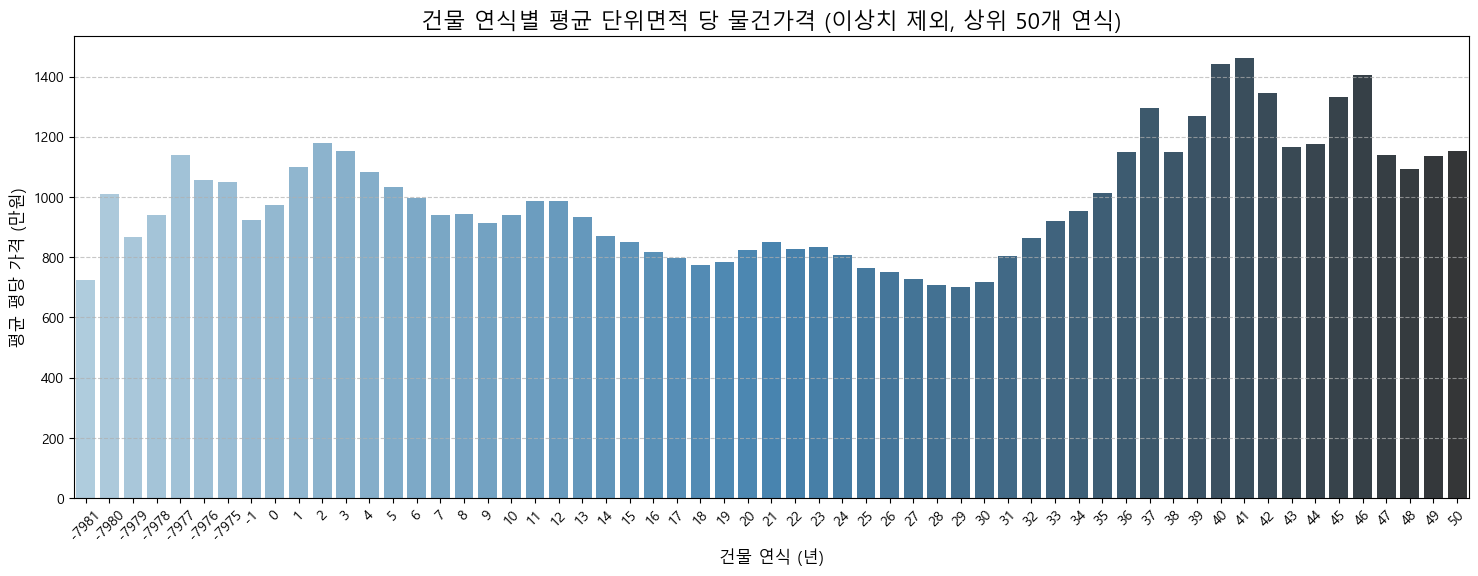

In [25]:
# --- 한글 폰트 설정 ---
system_name = platform.system()
if system_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system_name == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

plt.rc('axes', unicode_minus=False)
# ---------------------

# 1. 이상치(건축년도 0 등) 제거: 연식이 50년 이하인 데이터만 필터링
df_valid = df2[df2['CTRT_BLDG_AGE'] <= 50]

# 2. 해당 연식들의 평균 거래 금액(THING_AMT) 계산
avg_price_top50 = df_valid.groupby('CTRT_BLDG_AGE')['AMT_PER_AREA'].mean()

# 3. 연식 순서대로 정렬 (시간 흐름에 따른 가격 확인용)
avg_price_top50 = avg_price_top50.sort_index()

# 4. 시각화
plt.figure(figsize=(18, 6))
sns.barplot(x=avg_price_top50.index, y=avg_price_top50.values, palette='Blues_d')

plt.title('건물 연식별 평균 단위면적 당 물건가격 (이상치 제외, 상위 50개 연식)', fontsize=16)
plt.xlabel('건물 연식 (년)', fontsize=12)
plt.ylabel('평균 평당 가격 (만원)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\3165332410.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=head_50_price.index, y=head_50_price.values, ax=axes[0], palette='Blues_d')
C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\3165332410.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tail_50_volume.index, y=tail_50_volume.values, ax=axes[1], palette='Greens_d') # 색상 변경 (구분 위해)


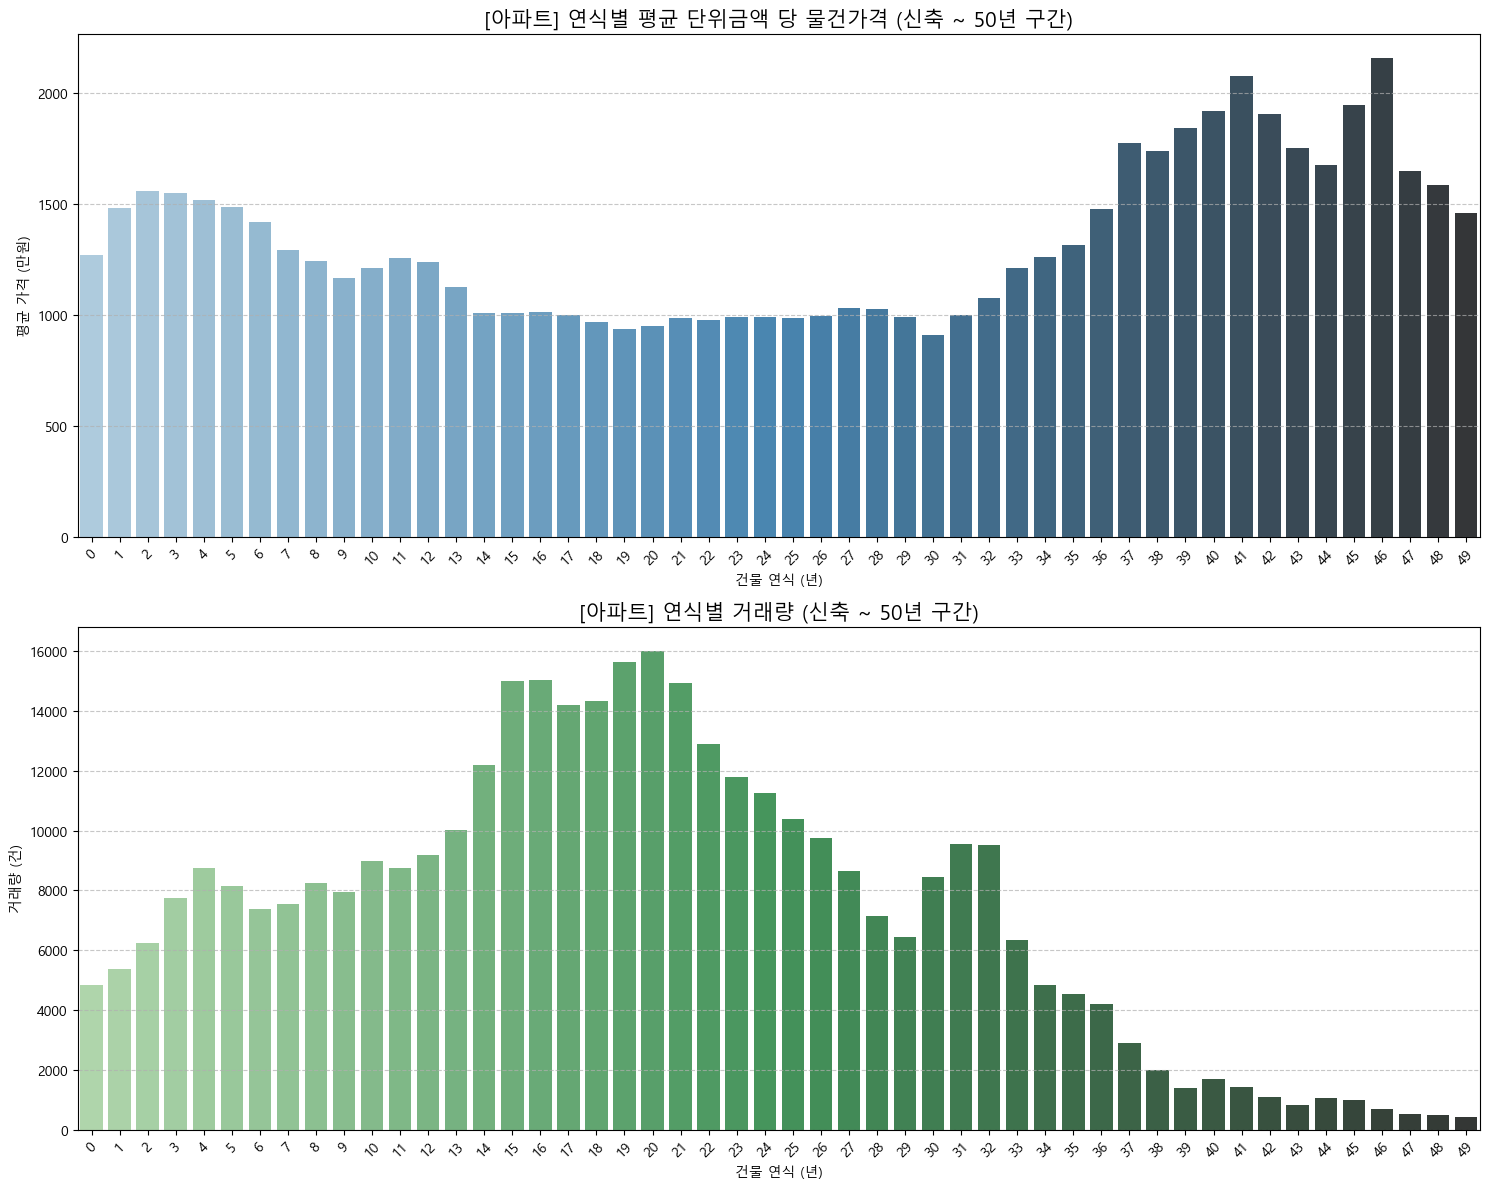

C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\3165332410.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=head_50_price.index, y=head_50_price.values, ax=axes[0], palette='Blues_d')
C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\3165332410.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tail_50_volume.index, y=tail_50_volume.values, ax=axes[1], palette='Greens_d') # 색상 변경 (구분 위해)


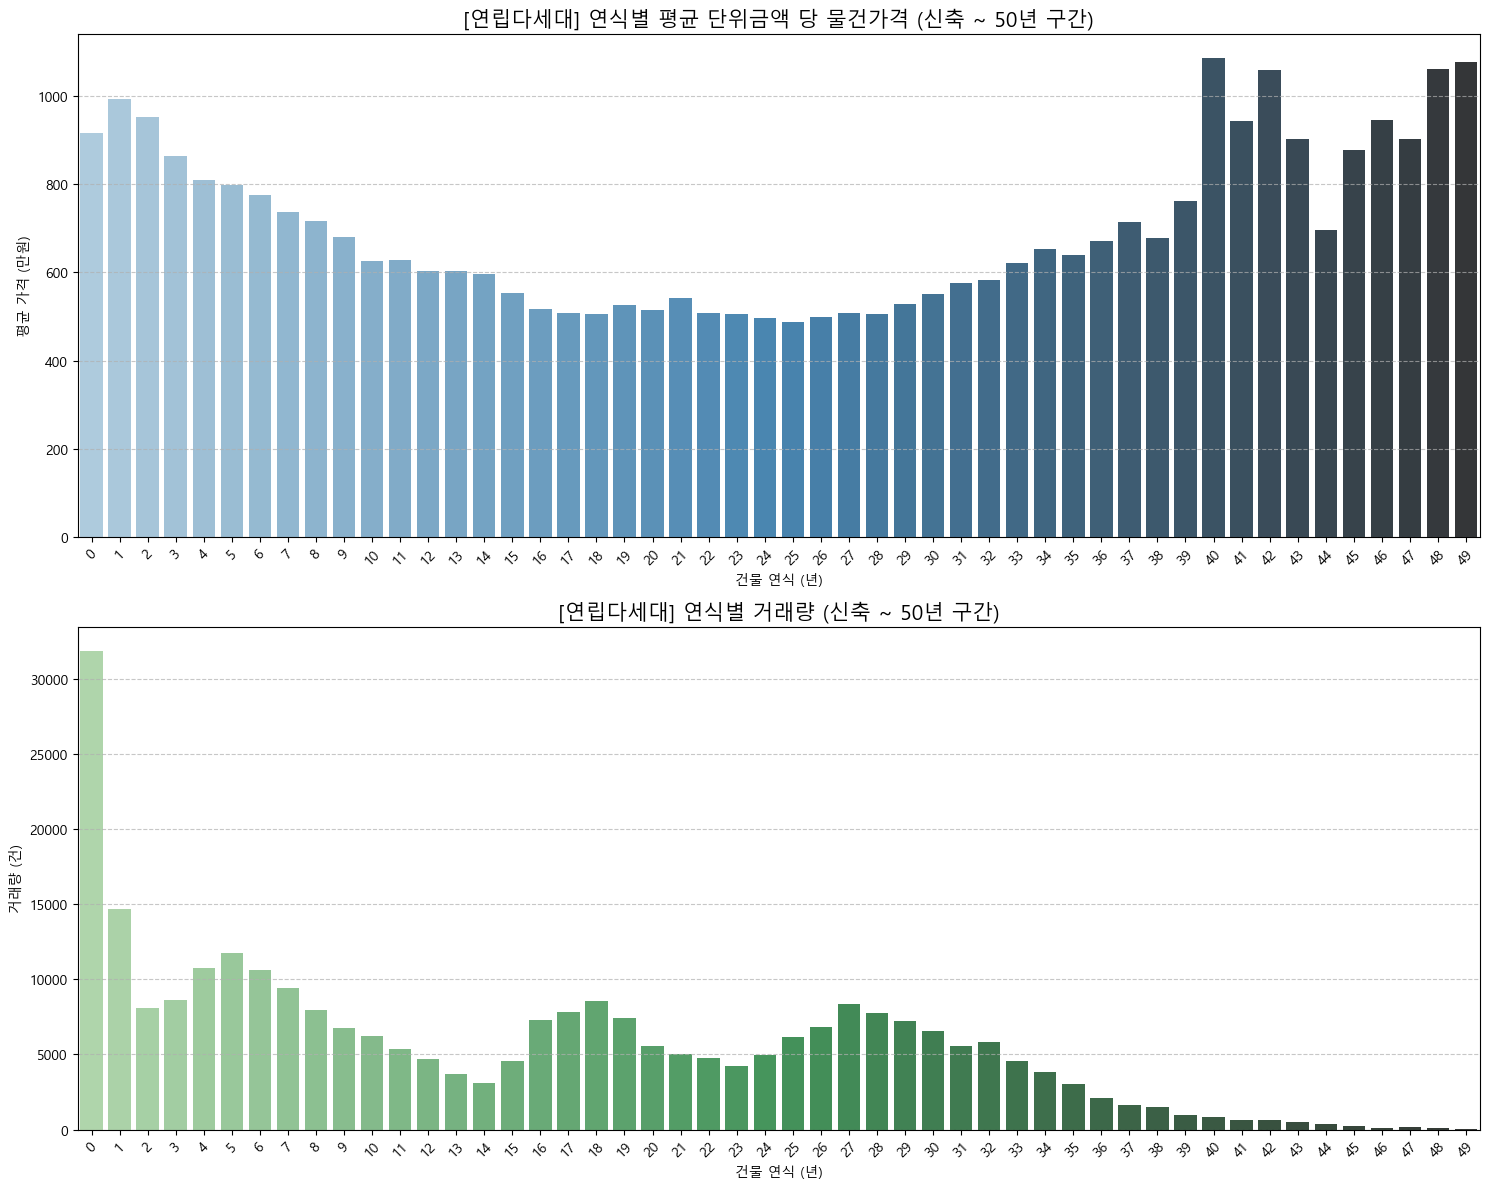

C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\3165332410.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=head_50_price.index, y=head_50_price.values, ax=axes[0], palette='Blues_d')
C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\3165332410.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tail_50_volume.index, y=tail_50_volume.values, ax=axes[1], palette='Greens_d') # 색상 변경 (구분 위해)


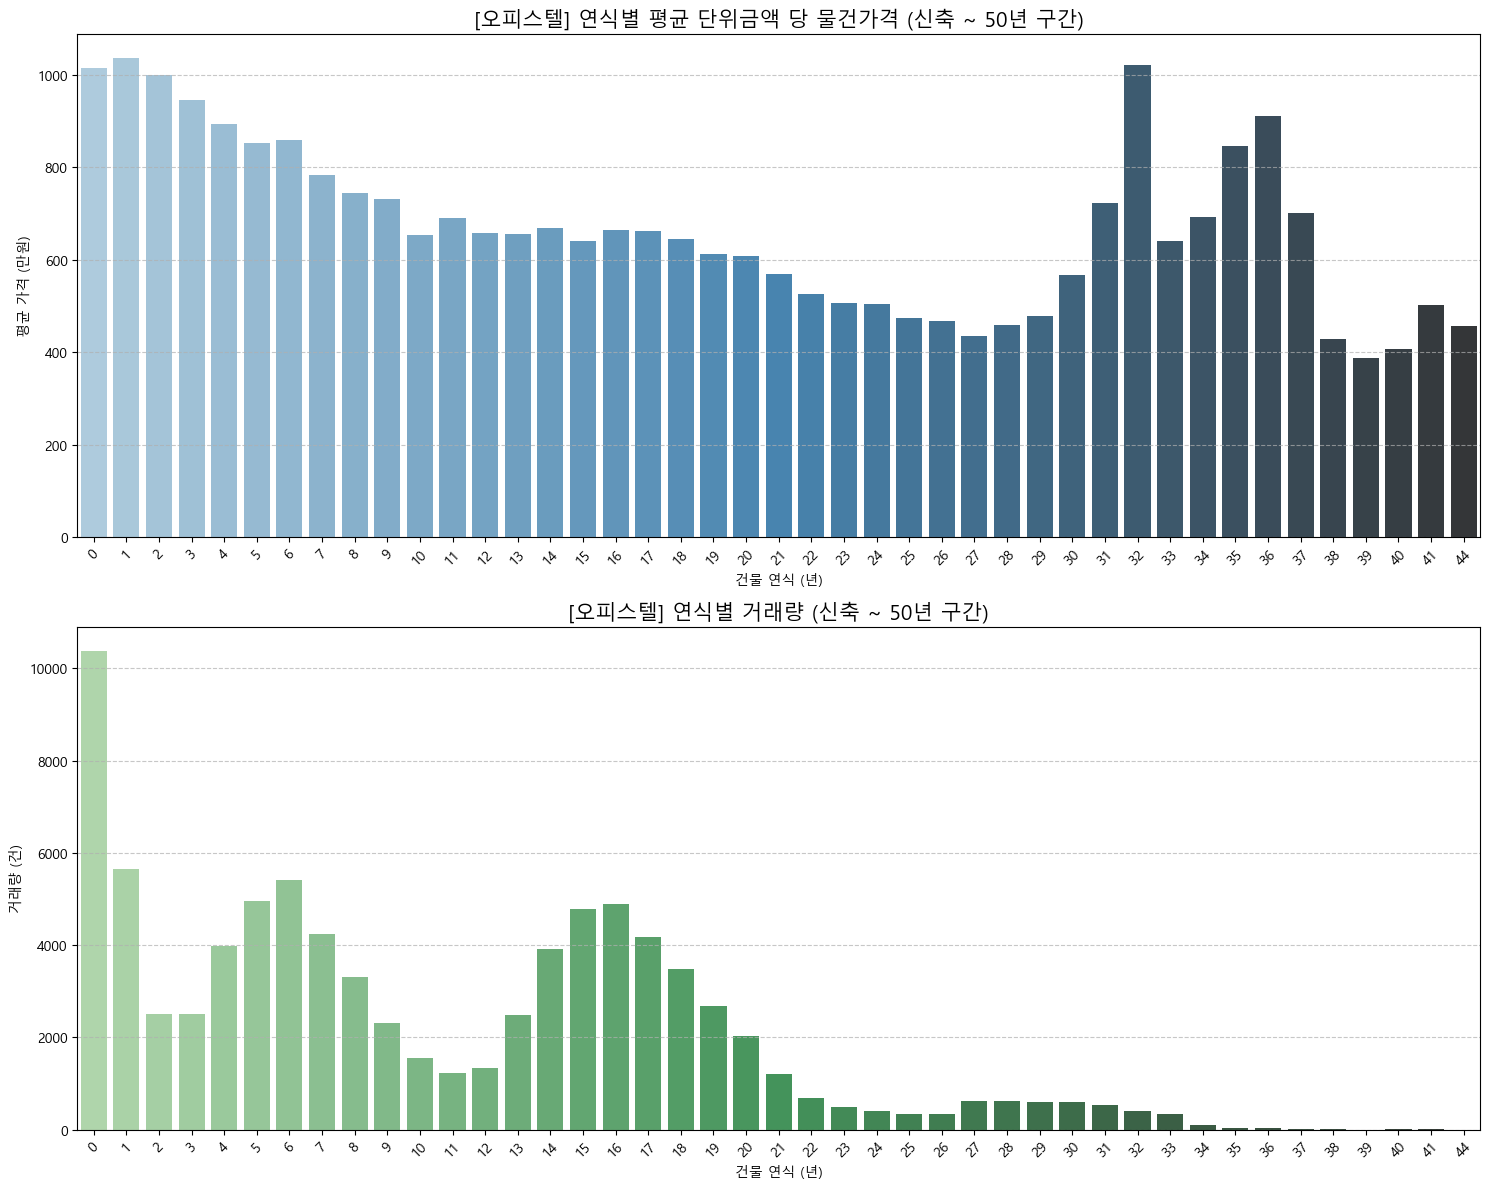

C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\3165332410.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=head_50_price.index, y=head_50_price.values, ax=axes[0], palette='Blues_d')
C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\3165332410.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tail_50_volume.index, y=tail_50_volume.values, ax=axes[1], palette='Greens_d') # 색상 변경 (구분 위해)


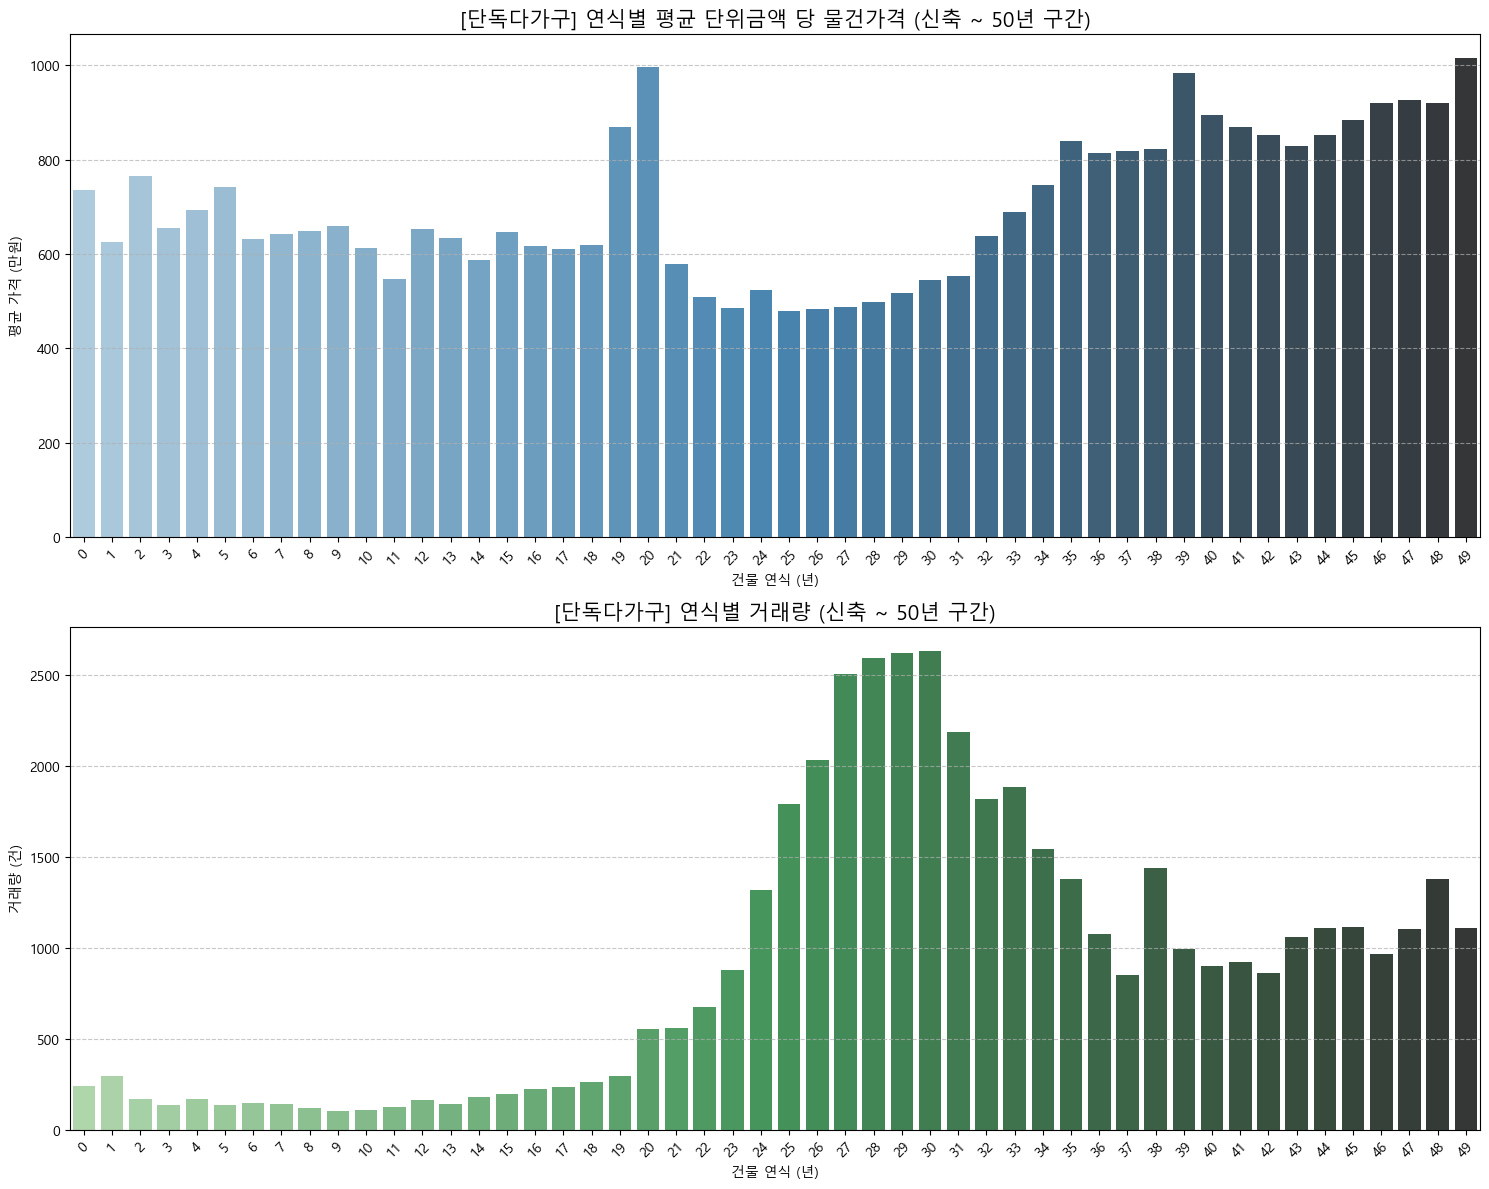

In [26]:
## 주택 용도 별 연식 별 평균

# 1. 0년 이상 150 이하 데이터만 필터링
df_valid_age = df2[(df2['CTRT_BLDG_AGE'] >= 0) & (df2['CTRT_BLDG_AGE'] < 150)]

# 2. 건물 용도 리스트 추출
building_types = df_valid_age['BLDG_USG'].unique()

for b_type in building_types:
    # 해당 용도의 데이터만 추출
    subset = df_valid_age[df_valid_age['BLDG_USG'] == b_type]
    
    # 1) 가격 통계 (평균)
    age_price = subset.groupby('CTRT_BLDG_AGE')['AMT_PER_AREA'].mean().sort_index()
    # 2) 거래량 통계 (건수) - "평균 거래량"은 통상 기간 평균을 의미하나, 여기선 해당 연식의 총 거래량으로 해석
    age_volume = subset.groupby('CTRT_BLDG_AGE')['AMT_PER_AREA'].count().sort_index()
    

    # --- 상위 50개 (신축 ~ 50년차): 가격 기준 ---
    head_50_price = age_price.head(50)
    
    # --- 하위 50개 (신축 ~ 50년차): 거래량 기준 ---
    tail_50_volume = age_volume.head(50)
    
    # 그래프 그리기
    fig, axes = plt.subplots(2, 1, figsize=(15, 12))
    
    # 1) 상위 50개 그래프 (평균 가격)
    sns.barplot(x=head_50_price.index, y=head_50_price.values, ax=axes[0], palette='Blues_d')
    axes[0].set_title(f'[{b_type}] 연식별 평균 단위금액 당 물건가격 (신축 ~ 50년 구간)', fontsize=15)
    axes[0].set_xlabel('건물 연식 (년)')
    axes[0].set_ylabel('평균 가격 (만원)')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # 2) 하위 50개 그래프 (거래량) - 변경됨
    sns.barplot(x=tail_50_volume.index, y=tail_50_volume.values, ax=axes[1], palette='Greens_d') # 색상 변경 (구분 위해)
    axes[1].set_title(f'[{b_type}] 연식별 거래량 (신축 ~ 50년 구간)', fontsize=15)
    axes[1].set_xlabel('건물 연식 (년)')
    axes[1].set_ylabel('거래량 (건)') # 라벨 변경
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\3414559693.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=head_50.index, y=head_50.values, ax=axes[0], palette='viridis')
C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\3414559693.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tail_50.index, y=tail_50.values, ax=axes[1], palette='magma')


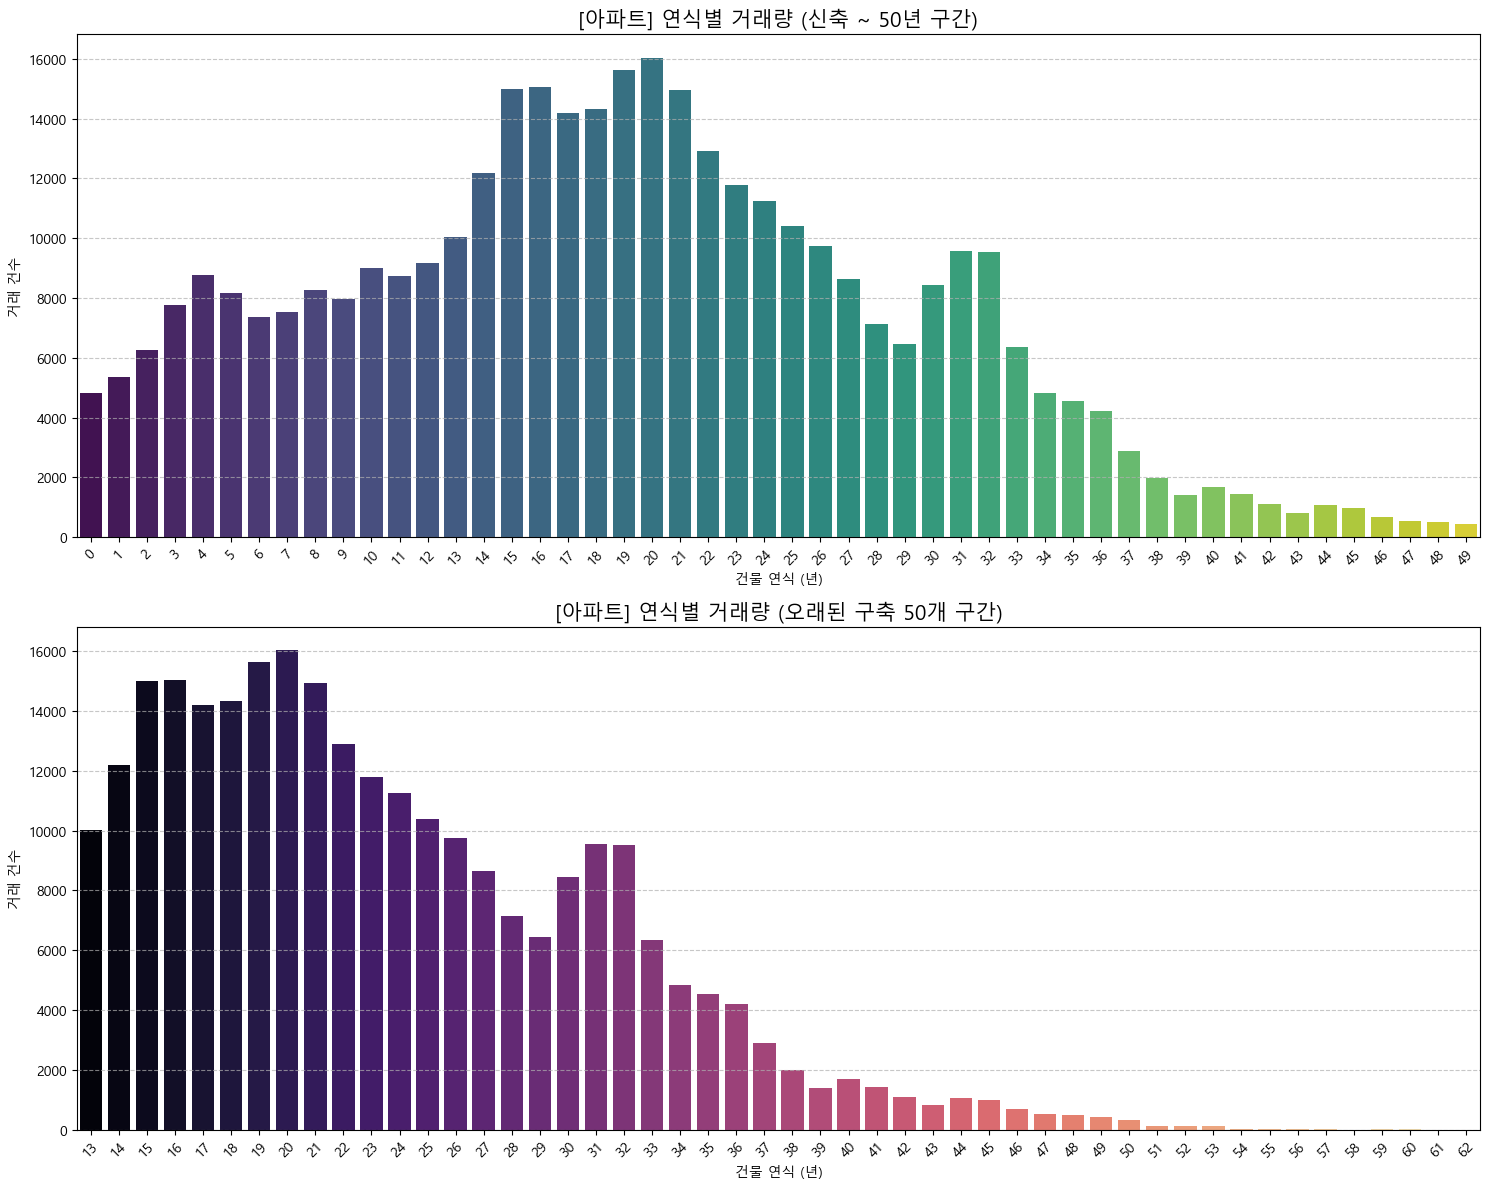

C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\3414559693.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=head_50.index, y=head_50.values, ax=axes[0], palette='viridis')
C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\3414559693.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tail_50.index, y=tail_50.values, ax=axes[1], palette='magma')


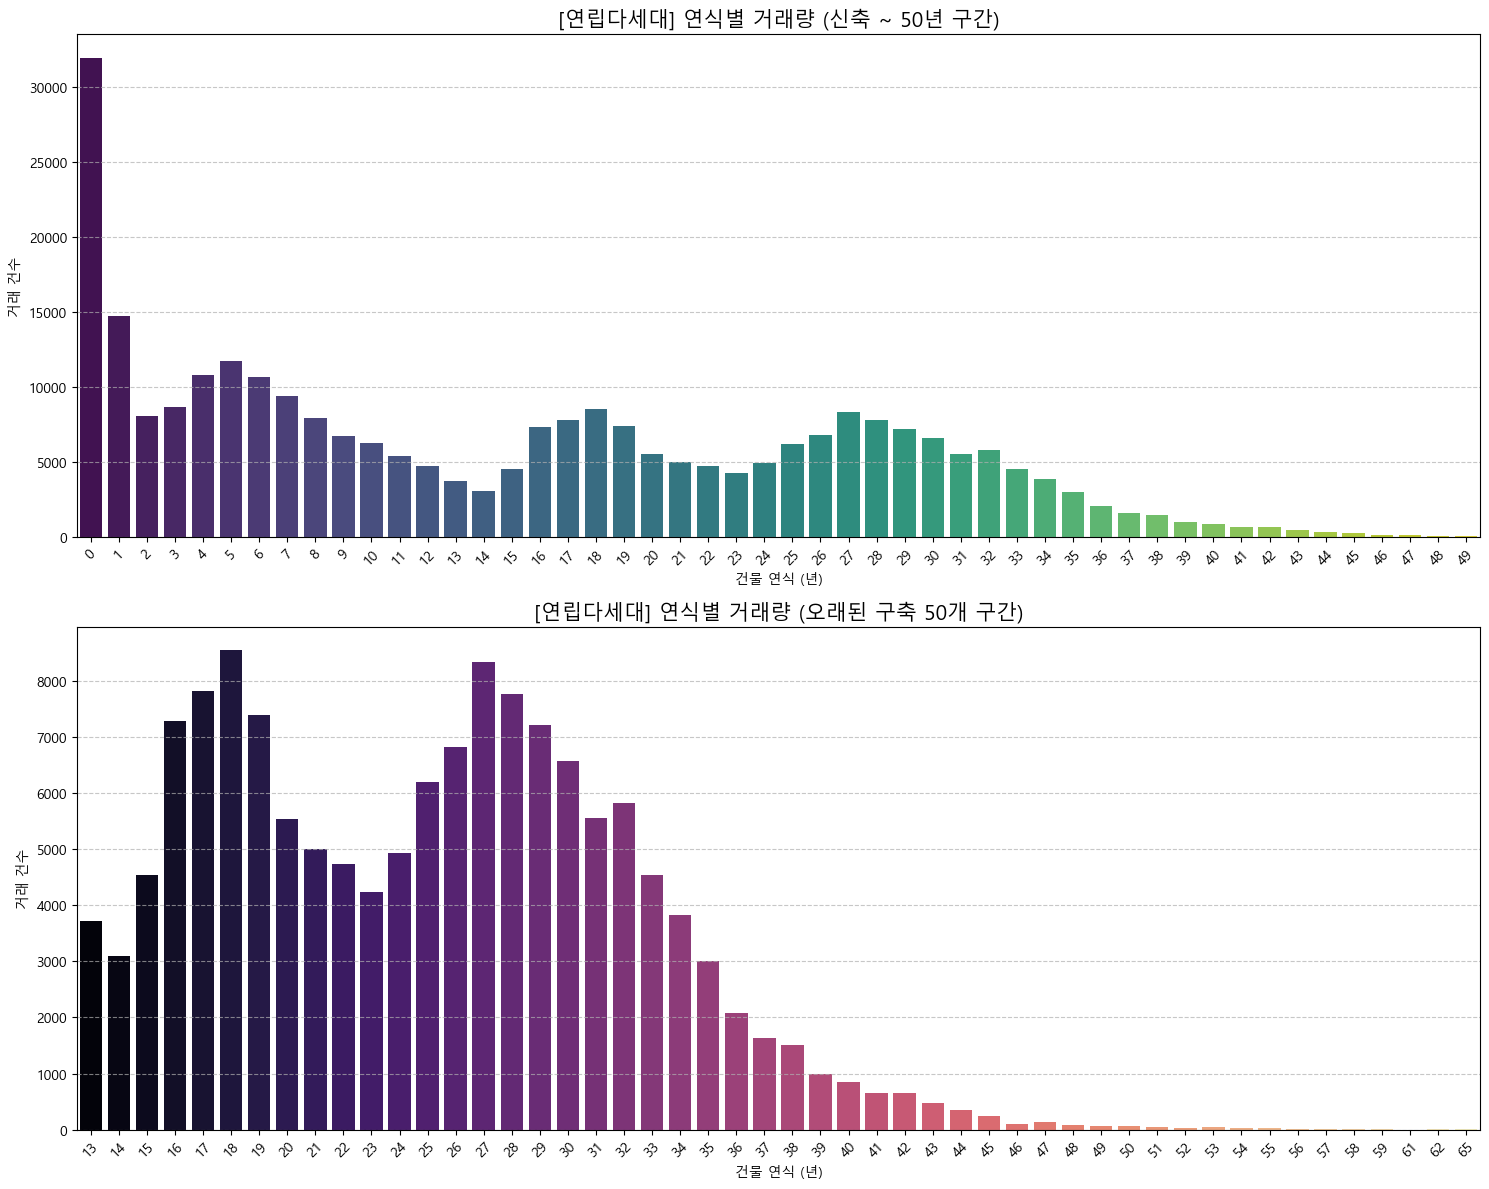

C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\3414559693.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=head_50.index, y=head_50.values, ax=axes[0], palette='viridis')
C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\3414559693.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tail_50.index, y=tail_50.values, ax=axes[1], palette='magma')


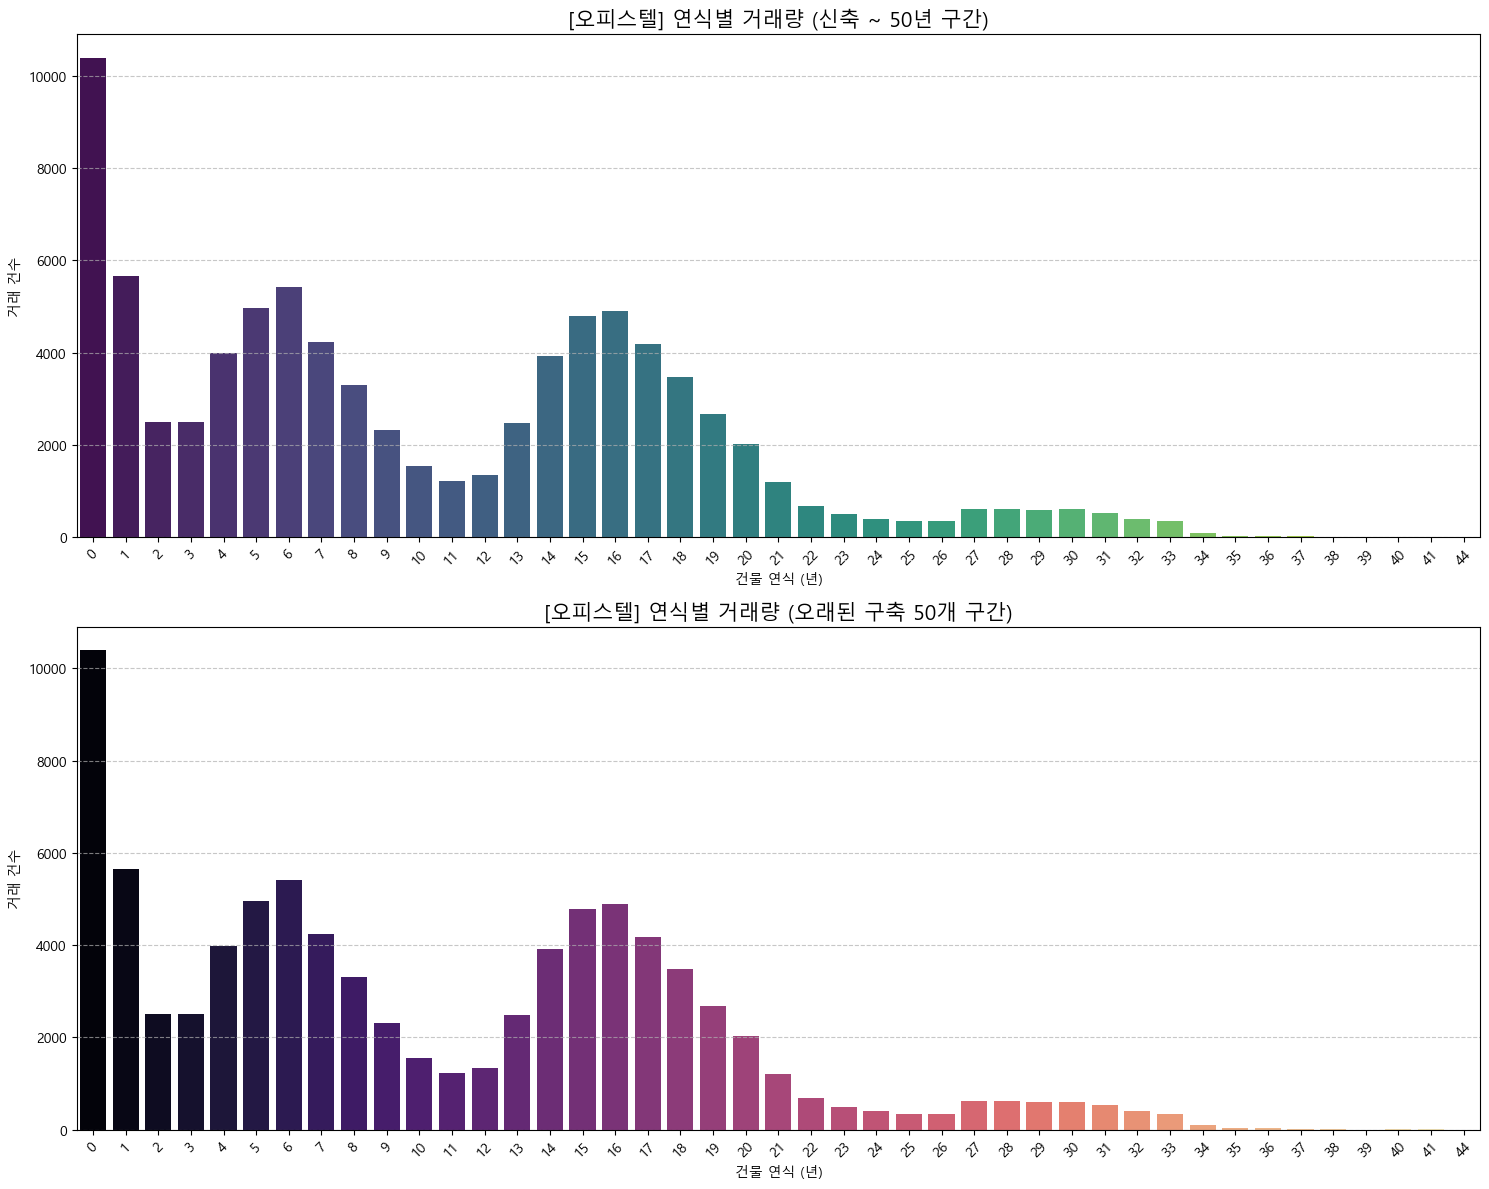

C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\3414559693.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=head_50.index, y=head_50.values, ax=axes[0], palette='viridis')
C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\3414559693.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tail_50.index, y=tail_50.values, ax=axes[1], palette='magma')


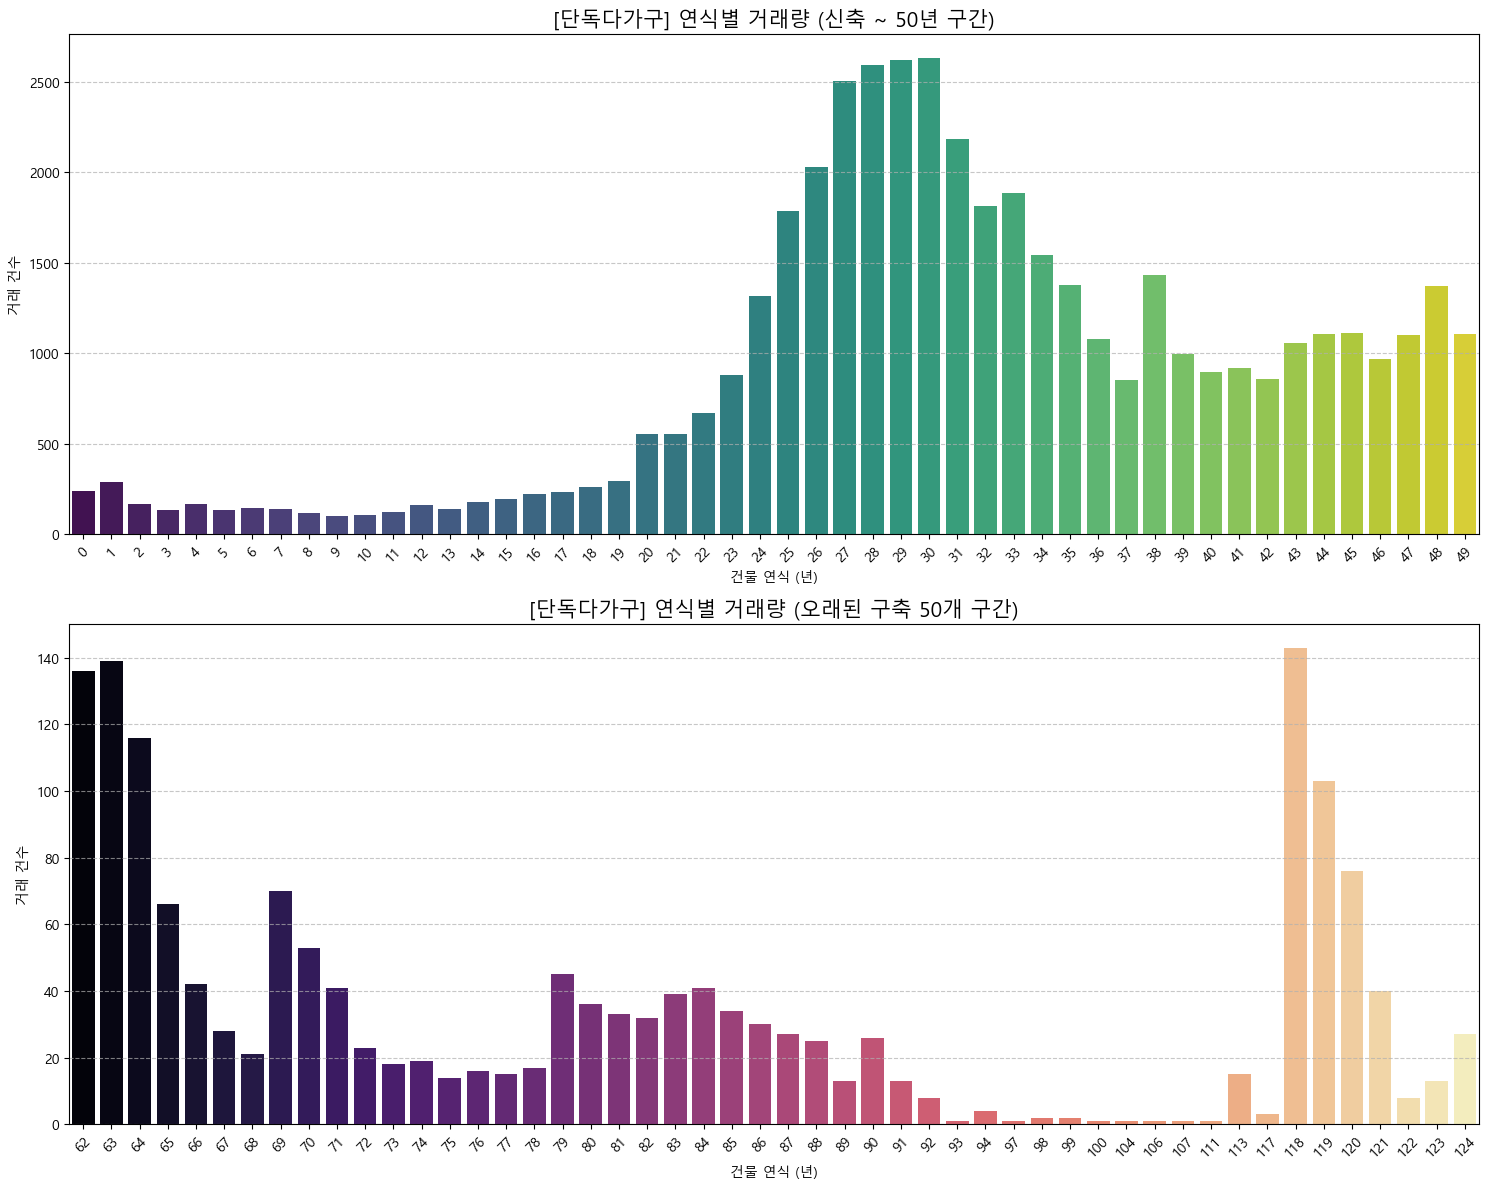

In [27]:
## 구축 vs 신축 거래량 비교(상위, 하위 50)

# 1. 0년 이상 150 이하 데이터만 필터링
df_valid_age = df2[(df2['CTRT_BLDG_AGE'] >= 0) & (df2['CTRT_BLDG_AGE'] < 150)]

# 2. 건물 용도 리스트 추출
building_types = df_valid_age['BLDG_USG'].unique()

for b_type in building_types:
    # 해당 용도의 데이터만 추출
    subset = df_valid_age[df_valid_age['BLDG_USG'] == b_type]
    
    # [수정됨] 평균(.mean) 대신 개수(.count) 또는 .value_counts() 사용
    # subset['CTRT_BLDG_AGE'] 컬럼 하나만 잡고 value_counts() 하는 것이 가장 간편합니다.
    age_counts = subset['CTRT_BLDG_AGE'].value_counts().sort_index()
    
    # --- 상위 50개 연식 구간 (신축 ~) ---
    head_50 = age_counts.head(50)
    
    # --- 하위 50개 연식 구간 (구축 ~) ---
    tail_50 = age_counts.tail(50)
    
    # 그래프 그리기
    fig, axes = plt.subplots(2, 1, figsize=(15, 12))
    
    # 1) 상위 50개 그래프 (신축 구간)
    sns.barplot(x=head_50.index, y=head_50.values, ax=axes[0], palette='viridis')
    axes[0].set_title(f'[{b_type}] 연식별 거래량 (신축 ~ 50년 구간)', fontsize=15)
    axes[0].set_xlabel('건물 연식 (년)')
    axes[0].set_ylabel('거래 건수')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # 2) 하위 50개 그래프 (구축 구간)
    sns.barplot(x=tail_50.index, y=tail_50.values, ax=axes[1], palette='magma')
    axes[1].set_title(f'[{b_type}] 연식별 거래량 (오래된 구축 50개 구간)', fontsize=15)
    axes[1].set_xlabel('건물 연식 (년)')
    axes[1].set_ylabel('거래 건수')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show() 

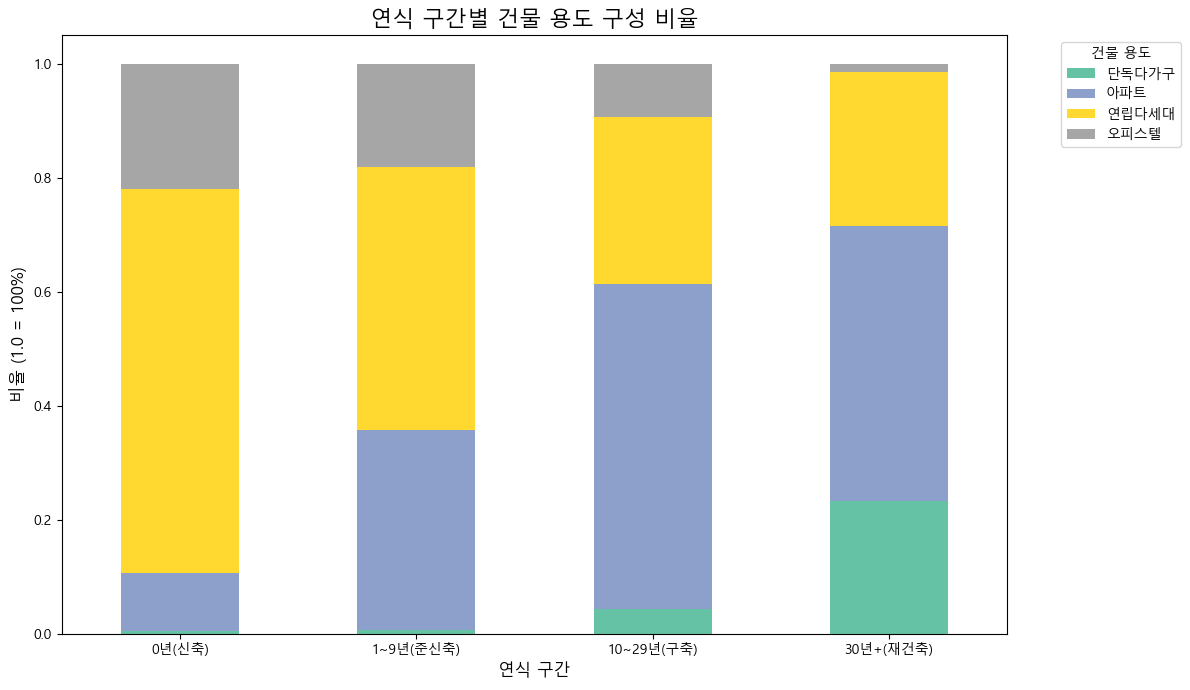

In [28]:
# 1. 데이터 복사 및 전처리 (음수 연식 제거)
df_valid = df2[df2['CTRT_BLDG_AGE'] >= 0].copy()

# 2. 연식 구간(Category) 정의 함수
def categorise_age(age):
    if age == 0:
        return '0년(신축)'
    elif 1 <= age <= 9:
        return '1~9년(준신축)'
    elif 10 <= age <= 29:
        return '10~29년(구축)'
    else: # 30년 이상
        return '30년+(재건축)'

# 3. 'Age_Group' 컬럼 생성
df_valid['Age_Group'] = df_valid['CTRT_BLDG_AGE'].apply(categorise_age)

# 4. 교차표(Crosstab) 생성: 인덱스=연식구간, 컬럼=건물용도
# normalize='index'를 사용하여 행별 합계가 1(100%)이 되도록 비율로 변환
age_type_ratio = pd.crosstab(df_valid['Age_Group'], df_valid['BLDG_USG'], normalize='index')

# 5. 인덱스(x축) 순서 지정 (논리적 순서대로 정렬)
desired_order = ['0년(신축)', '1~9년(준신축)', '10~29년(구축)', '30년+(재건축)']
age_type_ratio = age_type_ratio.reindex(desired_order)

# 6. 컬럼(범례) 순서 지정 (이미지와 유사하게)
# 데이터에 존재하는 용도만 선택하여 순서 지정
available_cols = age_type_ratio.columns.tolist()
# 원하는 순서 예시: 단독다가구 -> 아파트 -> 연립다세대 -> 오피스텔 (데이터에 있는 것만 남김)
target_cols_order = ['단독다가구', '아파트', '연립다세대', '오피스텔']
sorted_cols = [c for c in target_cols_order if c in available_cols]
# 만약 위 리스트에 없는 다른 용도가 있다면 뒤에 추가
remaining_cols = [c for c in available_cols if c not in sorted_cols]
final_cols = sorted_cols + remaining_cols

age_type_ratio = age_type_ratio[final_cols]

# 7. 색상 매핑 (이미지와 유사한 컬러 코드로 지정)
color_map = {
    '단독다가구': '#66c2a5', # 녹색 계열
    '아파트': '#8da0cb',     # 파란색 계열
    '연립다세대': '#ffd92f', # 노란색 계열
    '오피스텔': '#a6a6a6',   # 회색 계열
}
# 데이터에 있는 컬럼만 색상 리스트 생성
colors = [color_map.get(col, '#d3d3d3') for col in age_type_ratio.columns]

# 8. 그래프 그리기
ax = age_type_ratio.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 7), 
    color=colors,
    width=0.5 # 막대 너비 조절
)

plt.title('연식 구간별 건물 용도 구성 비율', fontsize=16)
plt.xlabel('연식 구간', fontsize=12)
plt.ylabel('비율 (1.0 = 100%)', fontsize=12)
plt.xticks(rotation=0) # x축 라벨 가로로 표시

# 범례 위치 조정 (그래프 밖 우측 상단)
plt.legend(title='건물 용도', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [29]:
# 0년 이하 등 이상치 제거 (필요시 사용, 여기선 0보다 큰 값만 사용)
target_df = df2.copy()

# 행: 건축년도(ARCH_YR), 열: 건물용도(BLDG_USG) 로 개수(count) 집계
table_counts = pd.crosstab(index=target_df['ARCH_YR'], columns=target_df['BLDG_USG'])

# 건축년도 순으로 정렬 (인덱스 정렬)
table_counts = table_counts.sort_index()

table_counts

# 전체 표를 엑셀로 저장하고 싶다면:
# table_counts.to_csv("building_year_counts.csv", encoding='euc-kr')

BLDG_USG,단독다가구,아파트,연립다세대,오피스텔
ARCH_YR,,,,
0,5,7039,0,0
970,1,0,0,0
1900,404,0,0,0
1901,9,0,0,0
1909,1,0,0,0
1911,15,0,0,0
1912,2,0,0,0
1920,2,0,0,0
1921,2,0,0,0


In [30]:
# 1. '단독다가구'이면서, 건축년도가 0 또는 970인 데이터 찾기
# (BLDG_USG 컬럼이 건물용도, ARCH_YR 컬럼이 건축년도라고 가정)
target_condition = (df2['BLDG_USG'] == '단독다가구') & (df2['ARCH_YR'].isin([0, 970]))

# 2. 조건에 맞는 데이터 조회
result_df = df2[target_condition]

# 3. 결과 확인
print(f"조건에 맞는 데이터 건수: {len(result_df)}건")
result_df

조건에 맞는 데이터 건수: 6건


,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR,CTRT_YR,CTRT_BLDG_AGE,AMT_PER_AREA
72626,11140,중구,16200,신당동,NaN,2018-06-15,39000,93,46,NaN,NaN,0,단독다가구,NaN,2018,2018,2018,421
624457,11140,중구,14400,장충동2가,NaN,2022-11-10,66600,79,69,NaN,NaN,0,단독다가구,중개거래,2022,2022,2022,839
634339,11170,용산구,12800,한강로3가,NaN,2022-08-17,300000,63,140,NaN,NaN,0,단독다가구,중개거래,2022,2022,2022,4794
700063,11500,강서구,10900,방화동,NaN,2023-09-26,137000,132,152,NaN,NaN,0,단독다가구,중개거래,2023,2023,2023,1036
739629,11110,종로구,14800,계동,NaN,2023-04-04,108000,44,86,NaN,NaN,970,단독다가구,중개거래,2023,2023,1053,2459
742464,11710,송파구,11400,마천동,NaN,2023-03-20,140000,437,179,NaN,NaN,0,단독다가구,중개거래,2023,2023,2023,320


In [31]:
# 1. 권리구분(RGHT_SE) 컬럼에 어떤 값들이 있는지 먼저 확인 (입주권, 분양권 등)
print(df2['RGHT_SE'].unique())
# 예상 출력: [nan, '입주권', '분양권'] 등

# 2. '입주권'인 데이터만 추출
df_movein = df2[df2['RGHT_SE'] == '입주권'].copy()

# 3. 결과 확인 (건수 및 데이터 샘플)
print(f"입주권 데이터 건수: {len(df_movein)}건")
display(df_movein.head(10))

# (참고) 입주권 데이터의 금액(THING_AMT) 통계 확인
print("\n입주권 금액 통계:")
print(df_movein['THING_AMT'].describe())

[nan '분양권' '입주권']
입주권 데이터 건수: 4650건


,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR,CTRT_YR,CTRT_BLDG_AGE,AMT_PER_AREA
771,11710,송파구,10700,가락동,송파 헬리오시티,2018-12-19,145803,85,0,26,입주권,0,아파트,NaN,2018,2018,2018,1716
967,11710,송파구,10700,가락동,송파 헬리오시티,2018-12-17,129679,60,0,10,입주권,0,아파트,NaN,2018,2018,2018,2163
1570,11290,성북구,13800,장위동,꿈의숲 아이파크,2018-12-10,60000,59,0,12,입주권,0,아파트,NaN,2018,2018,2018,1015
1785,11290,성북구,13800,장위동,꿈의숲 아이파크,2018-12-07,61020,59,0,16,입주권,0,아파트,NaN,2018,2018,2018,1032
1806,11290,성북구,13400,길음동,래미안 길음 센터피스,2018-12-07,90000,85,0,10,입주권,0,아파트,NaN,2018,2018,2018,1063
1936,11710,송파구,10700,가락동,송파 헬리오시티,2018-12-06,193500,110,0,28,입주권,0,아파트,NaN,2018,2018,2018,1752
2092,11680,강남구,10500,삼성동,래미안 라클래시,2018-12-05,360374,160,0,31,입주권,0,아파트,NaN,2018,2018,2018,2255
2174,11290,성북구,13300,정릉동,길음뉴타운 롯데캐슬 골든힐스,2018-12-04,49500,74,0,16,입주권,0,아파트,NaN,2018,2018,2018,669
2202,11710,송파구,10700,가락동,송파 헬리오시티,2018-12-04,142000,85,0,20,입주권,0,아파트,NaN,2018,2018,2018,1671
2609,11290,성북구,13800,장위동,래미안 장위포레카운티,2018-11-30,61531,60,0,10,입주권,0,아파트,NaN,2018,2018,2018,1027



입주권 금액 통계:
count      4650
mean     115724
std       67457
min       21000
25%       73000
50%       97000
75%      135000
max     1000000
Name: THING_AMT, dtype: float64


입주권/일반거래 가격 비율 하위 20개 (가격 차이가 큰 단지):


Movein_Price  \
CGG_NM STDG_NM BLDG_NM                   Area_Round                 
동작구    사당동     래미안 로이파크                  85                 66750   
중랑구    면목동     쌍용더플래티넘용마산                60                 40188   
동작구    사당동     이수역리가                     85                 63285   
은평구    진관동     마고정3단지센트레빌(310~322동)BL2-3 167                68683   
서초구    서초동     래미안 리더스원                  60                158140   
                                         115               215481   
서대문구   홍은동     북한산더샵                     115                83950   
중랑구    면목동     쌍용더플래티넘용마산                85                 65000   
용산구    효창동     용산케이씨씨스위첸                 60                 85000   
송파구    가락동     헬리오시티                     130               195000   
영등포구   당산동4가   당산롯데캐슬프레스티지               85                 89800   
성동구    금호동4가   힐스테이트서울숲리버                115               141734   
서대문구   북아현동    e편한세상신촌3단지                60                 78000   
성동구    금호동4가   힐스테이트서울숲리버                60                 89500   
동대문구   전농동     동대문 롯데캐슬 노블레스             85                 93250   
강남구    역삼동     대우디오빌                     30                 21000   
종로구    교북동     경희궁자이(4단지)                34                 52000   
동대문구   전농동     동대문 롯데캐슬 노블레스             60                 75441   
영등포구   신길동     래미안에스티움                   85                 89500   
동대문구   답십리동    답십리파크자이                   85                 82750   

                                                     Normal_Price  Price_Ratio  
CGG_NM STDG_NM BLDG_NM                   Area_Round                             
동작구    사당동     래미안 로이파크                  85                144426            0  
중랑구    면목동     쌍용더플래티넘용마산                60                 86506            0  
동작구    사당동     이수역리가                     85                117851            1  
은평구    진관동     마고정3단지센트레빌(310~322동)BL2-3 167               121324            1  
서초구    서초동     래미안 리더스원                  60                269000            1  
                                         115               358692            1  
서대문구   홍은동     북한산더샵                     115               136312            1  
중랑구    면목동     쌍용더플래티넘용마산                85                103929            1  
용산구    효창동     용산케이씨씨스위첸                 60                133800            1  
송파구    가락동     헬리오시티                     130               303100            1  
영등포구   당산동4가   당산롯데캐슬프레스티지               85                139229            1  
성동구    금호동4가   힐스테이트서울숲리버                115               219025            1  
서대문구   북아현동    e편한세상신촌3단지                60                119855            1  
성동구    금호동4가   힐스테이트서울숲리버                60                136238            1  
동대문구   전농동     동대문 롯데캐슬 노블레스             85                140371            1  
강남구    역삼동     대우디오빌                     30                 31570            1  
종로구    교북동     경희궁자이(4단지)                34                 78167            1  
동대문구   전농동     동대문 롯데캐슬 노블레스             60                112482            1  
영등포구   신길동     래미안에스티움                   85                132568            1  
동대문구   답십리동    답십리파크자이                   85                120215            1

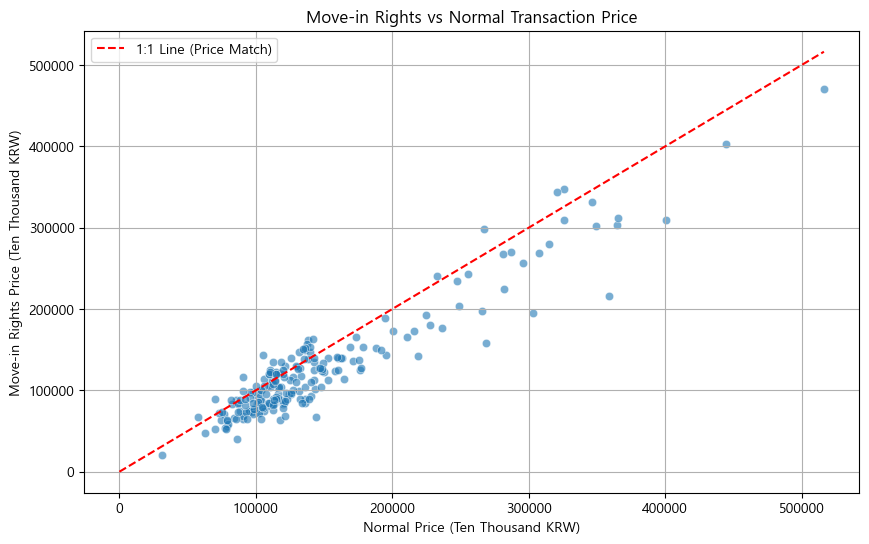


전체 비교 가능한 그룹 수: 208
입주권이 일반시세의 80% 미만인 그룹 수: 86


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 비교를 위한 전처리: 평형대 묶기 (전용면적을 정수로 반올림하여 그룹화)
df2['Area_Round'] = df2['ARCH_AREA'].round(0)

# 2. 입주권 vs 일반 거래 분리
# 입주권 데이터
df_movein = df2[df2['RGHT_SE'] == '입주권'].copy()
# 일반 거래 데이터 (권리구분이 없거나 입주권/분양권이 아닌 것 - 여기서는 NaN인 것을 일반 거래로 가정)
df_normal = df2[df2['RGHT_SE'].isna()].copy()

# 3. '자치구+동+단지명+평형' 기준으로 그룹화하여 평균 가격 계산
group_cols = ['CGG_NM', 'STDG_NM', 'BLDG_NM', 'Area_Round']

# 입주권 평균가
movein_price = df_movein.groupby(group_cols)['THING_AMT'].mean().rename('Movein_Price')
# 일반 거래 평균가
normal_price = df_normal.groupby(group_cols)['THING_AMT'].mean().rename('Normal_Price')

# 4. 두 데이터 합치기 (교집합만: 입주권과 일반거래가 *모두* 있는 단지/평형만 비교 가능)
merged = pd.concat([movein_price, normal_price], axis=1, join='inner')

# 5. 괴리율 계산 (입주권 가격 / 일반 가격)
merged['Price_Ratio'] = merged['Movein_Price'] / merged['Normal_Price']

# 6. 결과 출력: 괴리율이 낮은 순서대로 정렬 (가격 차이가 큰 순서)
# 비율이 1.0에 가까우면 비슷함, 0.5 근처면 입주권이 반값(추가분담금 미포함 가능성 높음)
print("입주권/일반거래 가격 비율 하위 20개 (가격 차이가 큰 단지):")
display(merged.sort_values(by='Price_Ratio').head(20))

# 7. 시각화: 가격 비교 산점도
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged, x='Normal_Price', y='Movein_Price', alpha=0.6)
plt.plot([0, merged['Normal_Price'].max()], [0, merged['Normal_Price'].max()], 'r--', label='1:1 Line (Price Match)')
plt.title('Move-in Rights vs Normal Transaction Price')
plt.xlabel('Normal Price (Ten Thousand KRW)')
plt.ylabel('Move-in Rights Price (Ten Thousand KRW)')
plt.legend()
plt.grid(True)
plt.show()

# 8. 결론 도출을 위한 통계값
print(f"\n전체 비교 가능한 그룹 수: {len(merged)}")
print(f"입주권이 일반시세의 80% 미만인 그룹 수: {len(merged[merged['Price_Ratio'] < 0.8])}")

In [34]:
# 1. 아파트만 추출
df_apt = df2[
    (df['BLDG_USG'] == '아파트')
].copy()

# 2. 비교 그룹 생성 (Future vs Existing)
# ARCH_YR가 0이면 'Future', 아니면 'Existing'으로 라벨링
df_apt['Type'] = np.where(df_apt['ARCH_YR'] == 0, 'Future(0)', 'Existing')

# 단위 면적당 가격 계산 (가격 / 전용면적)
df_apt['Unit_Price'] = df_apt['THING_AMT'] / df_apt['ARCH_AREA']

# 3. 동(Neighborhood)별 가격 비교 집계
# 동별, 타입별 평균 단위 가격 계산
stats = df_apt.groupby(['CGG_NM', 'STDG_NM', 'Type'])['Unit_Price'].mean().unstack()

# 4. 신뢰성 검증 지표 생성 (Price Ratio)
# Ratio = 미래 아파트 가격 / 현재 아파트 가격
# Ratio가 1보다 작으면(특히 0.8 미만) '가격 왜곡(분담금 누락)' 의심
stats['Price_Ratio'] = stats['Future(0)'] / stats['Existing']

# 5. 결과 확인
# 의심 지역 (Ratio < 0.8) 추출
suspicious_areas = stats[stats['Price_Ratio'] < 0.8].sort_values('Price_Ratio')

print("가격 데이터 신뢰성이 떨어지는(분담금 누락 의심) 지역:")
print(suspicious_areas[['Future(0)', 'Existing', 'Price_Ratio']])

가격 데이터 신뢰성이 떨어지는(분담금 누락 의심) 지역:
Type            Future(0)  Existing  Price_Ratio
CGG_NM STDG_NM                                  
성동구    마장동            667      1072            1
강서구    화곡동            502       804            1
은평구    진관동            574       892            1
구로구    항동             563       832            1
종로구    홍파동           1554      2155            1
용산구    이촌동           1389      1896            1
강서구    마곡동           1002      1352            1
양천구    목동            1045      1410            1
성북구    보문동1가         1308      1694            1
종로구    교북동           1530      1961            1
강동구    암사동            937      1185            1


C:\Users\gorhk\AppData\Local\Temp\ipykernel_54276\3901740095.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_apt = df2[


In [ ]:
# 최초의 오피스텔은 1985년
# https://realty.chosun.com/site/data/html_dir/2020/10/29/2020102902725.html
# '오피스텔' 중 건축년도가 1980년인 데이터 필터링
target_officetel = df2[(df2['BLDG_USG'] == '오피스텔') & (df2['ARCH_YR'] == 1980)]

# 결과 확인
print(f"조회된 데이터 건수: {len(target_officetel)}건")
target_officetel

조회된 데이터 건수: 10건


,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR,CTRT_YR,CTRT_BLDG_AGE,AMT_PER_AREA,Area_Round
85595,11740,강동구,10700,암사동,강동리시온,2018-05-10,12300,28,40,3,NaN,1980,오피스텔,NaN,2018,2018,38,432,28
102136,11740,강동구,10700,암사동,강동리시온,2018-03-26,15000,35,49,4,NaN,1980,오피스텔,NaN,2018,2018,38,427,35
271081,11740,강동구,10700,암사동,강동리시온,2019-04-18,11000,28,40,3,NaN,1980,오피스텔,NaN,2019,2019,39,387,28
425712,11740,강동구,10700,암사동,강동리시온,2020-04-06,13400,28,40,3,NaN,1980,오피스텔,NaN,2020,2020,40,471,28
429306,11740,강동구,10700,암사동,강동리시온,2020-03-23,5900,17,24,3,NaN,1980,오피스텔,NaN,2020,2020,40,348,17
437504,11740,강동구,10700,암사동,강동리시온,2020-03-02,13000,28,40,4,NaN,1980,오피스텔,NaN,2020,2020,40,457,28
454917,11740,강동구,10700,암사동,강동리시온,2020-01-29,5900,17,24,4,NaN,1980,오피스텔,NaN,2020,2020,40,348,17
565579,11740,강동구,10700,암사동,강동리시온,2021-04-23,13900,28,40,5,NaN,1980,오피스텔,NaN,2021,2021,41,489,28
612809,11740,강동구,10700,암사동,강동리시온,2021-01-04,13000,25,35,4,NaN,1980,오피스텔,NaN,2021,2021,41,514,25
756434,11740,강동구,10700,암사동,강동리시온,2024-10-07,13000,28,40,4,NaN,1980,오피스텔,중개거래,2024,2024,44,457,28


C:\Users\gorhk\AppData\Local\Temp\ipykernel_52576\3293240536.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_volume = df_rights.set_index('CTRT_DAY').groupby(['RGHT_SE']).resample('M').size().reset_index(name='COUNT')
C:\Users\gorhk\AppData\Local\Temp\ipykernel_52576\3293240536.py:4: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_volume = df_rights.set_index('CTRT_DAY').groupby(['RGHT_SE']).resample('M').size().reset_index(name='COUNT')


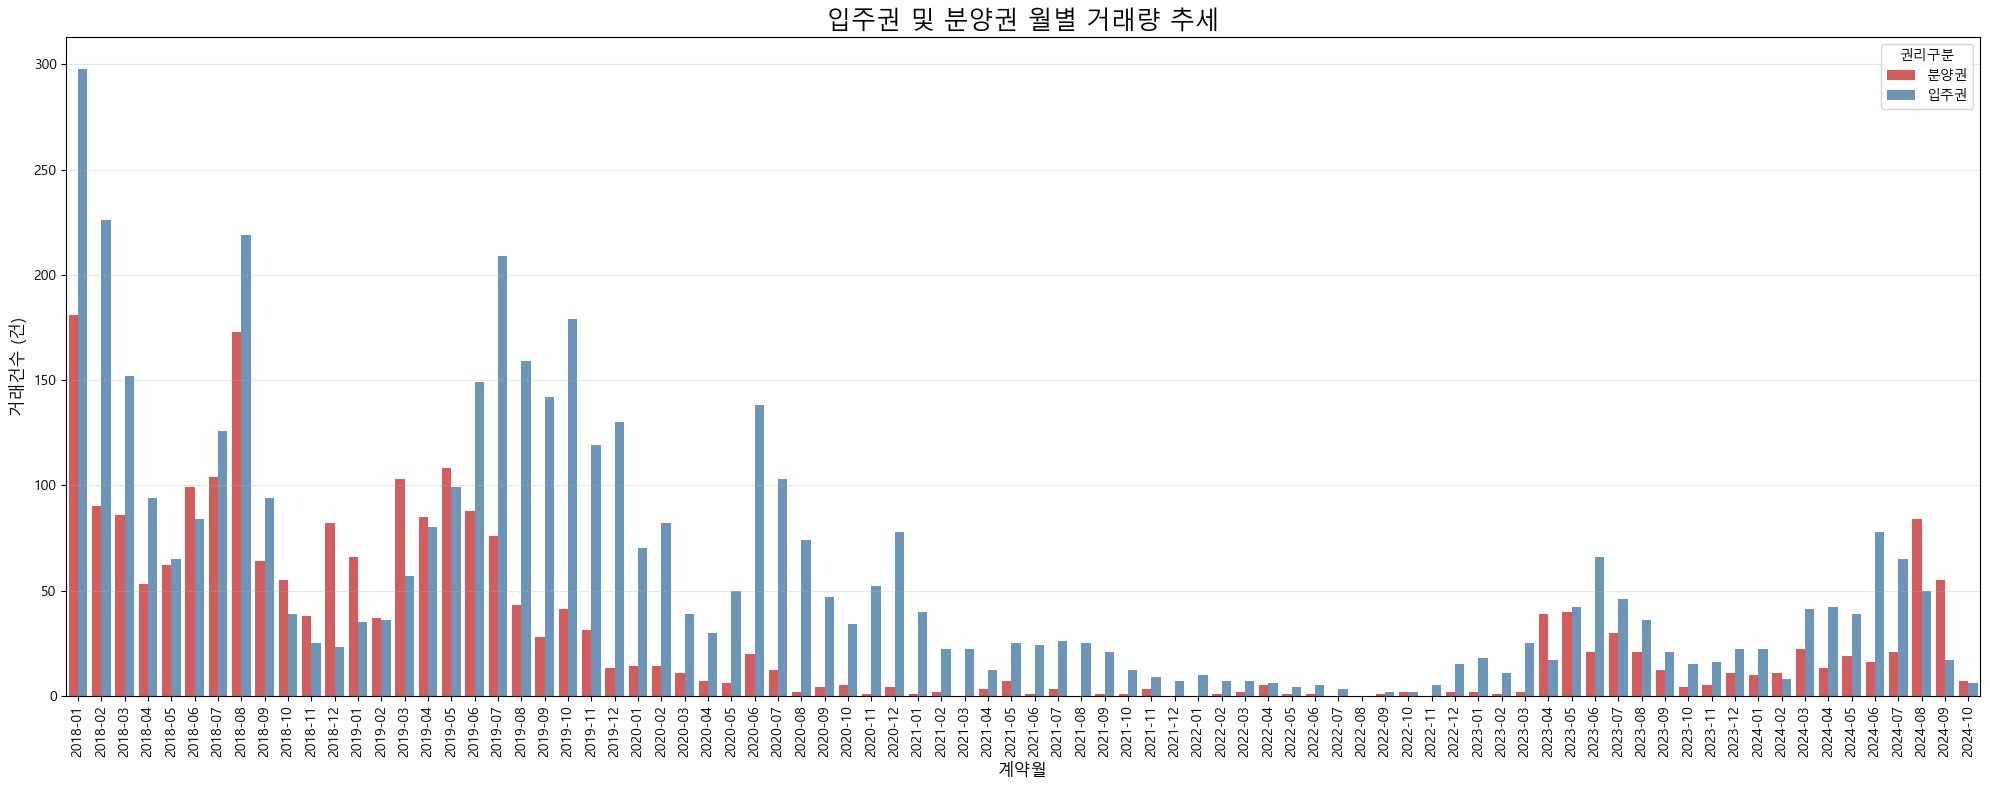

In [ ]:
# --- 거래량 시각화 (월별, 모든 날짜 표시) ---

# 1. 월별 리샘플링
df_volume = df_rights.set_index('CTRT_DAY').groupby(['RGHT_SE']).resample('M').size().reset_index(name='COUNT')

# 2. X축용 '년-월' 문자열 컬럼 생성 (이걸로 그려야 축이 마음대로 생략되지 않습니다)
df_volume['YYYYMM'] = df_volume['CTRT_DAY'].dt.strftime('%Y-%m')

# 3. 그래프 그리기
plt.figure(figsize=(20, 8)) # 가로를 좀 더 길게 설정

# hue를 사용하여 입주권/분양권 분리
sns.barplot(data=df_volume, x='YYYYMM', y='COUNT', hue='RGHT_SE', palette='Set1', alpha=0.8)

plt.title('입주권 및 분양권 월별 거래량 추세', fontsize=18)
plt.xlabel('계약월', fontsize=12)
plt.ylabel('거래건수 (건)', fontsize=12)

# X축 레이블 회전 (90도)
plt.xticks(rotation=90)

plt.grid(True, axis='y', alpha=0.3)
plt.legend(title='권리구분')
plt.tight_layout() # 잘림 방지
plt.show()

In [ ]:
# '입주권'인 행 제거 (권리구분이 '입주권'이 아닌 데이터만 남김)
df2 = df2[df2['RGHT_SE'] != '입주권'].copy()

# 또는 drop을 명시적으로 사용하는 방법 (인덱스를 알 필요 없음)
# index_to_drop = df2[df2['RGHT_SE'] == '입주권'].index
# df2 = df2.drop(index_to_drop)

# 필터링 후 확인
print(f"입주권 제거 후 남은 데이터 건수: {len(df2)}건")
print(df2['RGHT_SE'].unique()) # '입주권'이 사라졌는지 확인

입주권 제거 후 남은 데이터 건수: 789956건
[nan '분양권']
